# **Importing Data**, **Libraries** & **Inital Checks**

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re

from plotnine import *
from collections import defaultdict
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Importing the hourly-data
main = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour.csv")
backup = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour.csv")

In [5]:
df = main
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
# Checking the shape of the hourly-dataset
df.shape

(17379, 17)



---



# **Data Cleaning** & **Pre-processing**

In [7]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61




---



Variable **Description**

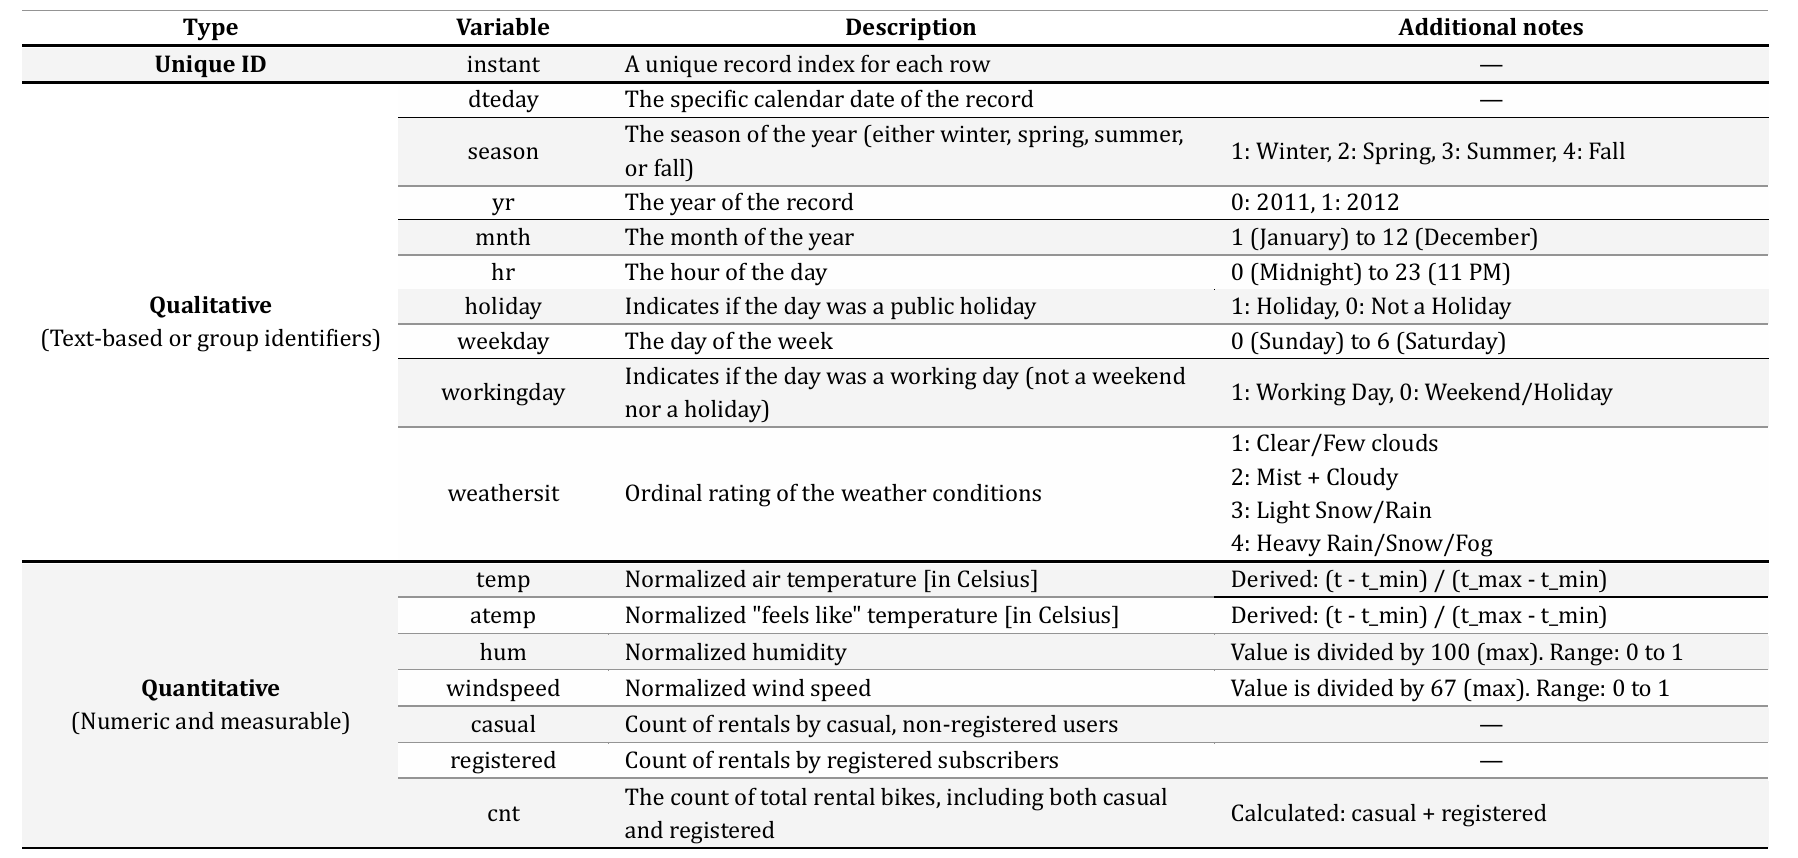

* **Part 1**: Dropping **Irrelevant** Columns

In [8]:
df = df.drop('instant', axis=1)

* **Part 2**: Data Type **Conversion** & **Validation**

In [9]:
# Categorical Variables (qualitative / text-based or group identifiers)
cats = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

# Quantitative Variables (numeric and measurable)
quants = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

**Categorical** Variables

In [10]:
# Convert 'dteday' to 'datetime' with error coercion FIRST
df['dteday'] = pd.to_datetime(df['dteday'], errors='coerce')

# Convert other columns to 'category' data type
df[cats] = df[cats].astype('category')


print("Data Types after conversion:")
print(df.dtypes)
print("\nCategory variables and their levels:")
for col in cats:
    print(f"{col}: {df[col].cat.categories.tolist()}")

print("\nDatetime variables:")
print(f"dteday: {df['dteday'].dtype}")

Data Types after conversion:
dteday        datetime64[ns]
season              category
yr                  category
mnth                category
hr                  category
holiday             category
weekday             category
workingday          category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

Category variables and their levels:
season: [1, 2, 3, 4]
yr: [0, 1]
mnth: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
hr: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
holiday: [0, 1]
weekday: [0, 1, 2, 3, 4, 5, 6]
workingday: [0, 1]
weathersit: [1, 2, 3, 4]

Datetime variables:
dteday: datetime64[ns]


In [11]:
# Summary statistics on 'Categorical' variables
df_cats = df.loc[:,cats]
df_cats.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit
count,17379,17379,17379,17379,17379,17379,17379,17379
unique,4,2,12,24,2,7,2,4
top,3,1,7,16,0,6,1,1
freq,4496,8734,1488,730,16879,2512,11865,11413


In [12]:
# Checking unique datapoints in 'Categorical' variables
for i in cats:
  print(df[i].value_counts())

season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64
yr
1    8734
0    8645
Name: count, dtype: int64
mnth
7     1488
5     1488
12    1483
8     1475
3     1473
10    1451
6     1440
4     1437
9     1437
11    1437
1     1429
2     1341
Name: count, dtype: int64
hr
16    730
17    730
15    729
14    729
13    729
12    728
18    728
19    728
20    728
21    728
22    728
23    728
8     727
9     727
10    727
7     727
11    727
0     726
6     725
1     724
5     717
2     715
4     697
3     697
Name: count, dtype: int64
holiday
0    16879
1      500
Name: count, dtype: int64
weekday
6    2512
0    2502
5    2487
1    2479
3    2475
4    2471
2    2453
Name: count, dtype: int64
workingday
1    11865
0     5514
Name: count, dtype: int64
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64




---



**Quanitative** Variables

In [13]:
# Summary statistics on 'Quantitative' variables
df_quants = df.loc[:,quants]
df_quants.describe()

,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [14]:
# Checking integers available in integer 'Quantitative' variables
for i in quants:
  print(i, df[i].unique())

temp [0.24 0.22 0.2  0.32 0.38 0.36 0.42 0.46 0.44 0.4  0.34 0.3  0.26 0.16
 0.14 0.18 0.12 0.28 0.1  0.08 0.06 0.04 0.02 0.52 0.56 0.58 0.6  0.48
 0.54 0.5  0.66 0.64 0.62 0.68 0.7  0.74 0.76 0.72 0.78 0.82 0.8  0.86
 0.88 0.9  0.84 0.92 0.94 0.96 0.98 1.  ]
atemp [0.2879 0.2727 0.2576 0.3485 0.3939 0.3333 0.4242 0.4545 0.4394 0.4091
 0.2273 0.2121 0.197  0.1667 0.1364 0.1061 0.1212 0.1818 0.2424 0.1515
 0.3182 0.0606 0.0758 0.0909 0.303  0.0303 0.0455 0.     0.0152 0.3636
 0.5    0.5303 0.5455 0.5909 0.4697 0.5152 0.6212 0.6061 0.4848 0.3788
 0.6364 0.6515 0.6667 0.5758 0.5606 0.6818 0.697  0.7424 0.7727 0.7576
 0.7273 0.7121 0.803  0.7879 0.8333 0.8182 0.8485 0.8788 0.8636 0.8939
 0.9242 0.9091 0.9545 0.9848 1.    ]
hum [0.81 0.8  0.75 0.86 0.76 0.77 0.72 0.82 0.88 0.87 0.94 1.   0.71 0.66
 0.57 0.46 0.42 0.39 0.44 0.47 0.5  0.43 0.4  0.35 0.3  0.32 0.64 0.69
 0.55 0.59 0.63 0.68 0.74 0.51 0.56 0.52 0.49 0.48 0.37 0.33 0.28 0.38
 0.36 0.93 0.29 0.53 0.34 0.54 0.41 0.45 0.92 0.62 0.5



---



Data **Range Validation** for both **Categorical** & **Quantitative Variables**

In [15]:
def validate_data_ranges(df):

    # Define expected ranges for ALL variables
    expected_ranges = {
        # Categorical variables
        'season': {'min': 1, 'max': 4, 'type': 'categorical'},
        'yr': {'min': 0, 'max': 1, 'type': 'categorical'},
        'mnth': {'min': 1, 'max': 12, 'type': 'categorical'},
        'hr': {'min': 0, 'max': 23, 'type': 'categorical'},
        'holiday': {'min': 0, 'max': 1, 'type': 'categorical'},
        'weekday': {'min': 0, 'max': 6, 'type': 'categorical'},
        'workingday': {'min': 0, 'max': 1, 'type': 'categorical'},
        'weathersit': {'min': 1, 'max': 4, 'type': 'categorical'},

        # Quantitative variables (normalized)
        'temp': {'min': 0, 'max': 1, 'type': 'quantitative'},
        'atemp': {'min': 0, 'max': 1, 'type': 'quantitative'},
        'hum': {'min': 0, 'max': 1, 'type': 'quantitative'},
        'windspeed': {'min': 0, 'max': 1, 'type': 'quantitative'},
        'casual': {'min': 0, 'max': None, 'type': 'quantitative'},
        'registered': {'min': 0, 'max': None, 'type': 'quantitative'},
        'cnt': {'min': 0, 'max': None, 'type': 'quantitative'}
    }

    validation_results = []

    for col, specs in expected_ranges.items():
        if col not in df.columns:
            print(f"❌ Column '{col}' not found in dataframe")
            continue

        # Convert categorical columns to ordered before calculating min/max
        if specs['type'] == 'categorical':
            df[col] = df[col].cat.as_ordered()

        min_val = df[col].min()
        max_val = df[col].max()
        null_count = df[col].isnull().sum()

        # Check if values are within expected range
        within_min = min_val >= specs['min'] if specs['min'] is not None else True
        within_max = max_val <= specs['max'] if specs['max'] is not None else True
        has_nulls = null_count > 0

        status = "PASS"
        if not within_min or not within_max or has_nulls:
            status = "FAIL"

        validation_results.append({
            'column': col,
            'type': specs['type'],
            'min_value': min_val,
            'max_value': max_val,
            'null_count': null_count,
            'expected_min': specs['min'],
            'expected_max': specs['max'],
            'status': status
        })

        if status == "PASS":
            print(f"✅ {col:12} | Range: [{min_val:6.3f}, {max_val:6.3f}] | No. of Missing Values: {null_count:2} | {specs['type']:12}")
        else:
            print(f"❌ {col:12} | Range: [{min_val:6.3f}, {max_val:6.3f}] | No. of Missing Values: {null_count:2} | {specs['type']:12}")
            if not within_min:
                print(f"   ‼️ Minimum value {min_val} below expected {specs['min']}")
            if not within_max:
                print(f"   ‼️ Maximum value {max_val} above expected {specs['max']}")
            if has_nulls:
                print(f"   ‼️ Contains {null_count} null values")

    return pd.DataFrame(validation_results)

validation_df = validate_data_ranges(df)

✅ season       | Range: [ 1.000,  4.000] | No. of Missing Values:  0 | categorical 
✅ yr           | Range: [ 0.000,  1.000] | No. of Missing Values:  0 | categorical 
✅ mnth         | Range: [ 1.000, 12.000] | No. of Missing Values:  0 | categorical 
✅ hr           | Range: [ 0.000, 23.000] | No. of Missing Values:  0 | categorical 
✅ holiday      | Range: [ 0.000,  1.000] | No. of Missing Values:  0 | categorical 
✅ weekday      | Range: [ 0.000,  6.000] | No. of Missing Values:  0 | categorical 
✅ workingday   | Range: [ 0.000,  1.000] | No. of Missing Values:  0 | categorical 
✅ weathersit   | Range: [ 1.000,  4.000] | No. of Missing Values:  0 | categorical 
✅ temp         | Range: [ 0.020,  1.000] | No. of Missing Values:  0 | quantitative
✅ atemp        | Range: [ 0.000,  1.000] | No. of Missing Values:  0 | quantitative
✅ hum          | Range: [ 0.000,  1.000] | No. of Missing Values:  0 | quantitative
✅ windspeed    | Range: [ 0.000,  0.851] | No. of Missing Values:  0 | quant



---



Perform Comprehensive **Data Integrity** Checks

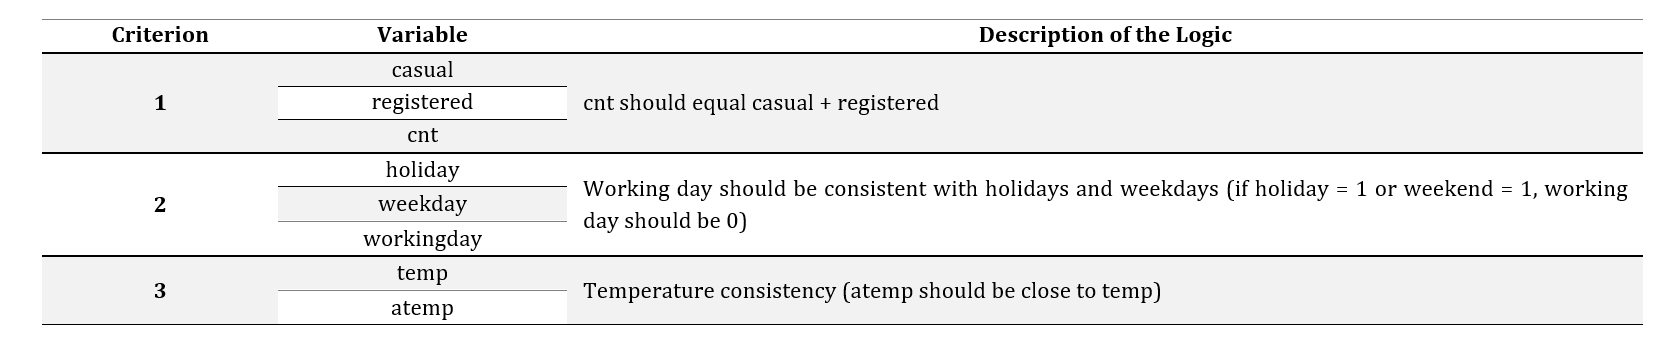

In [16]:
def data_integrity_checks(df):

    integrity_issues = []
    df_clean = df.copy()

    # Initialize dataframes to empty in case the conditions are not met
    mismatches = pd.DataFrame()
    logic_check = pd.DataFrame()
    large_temp_diff_records = pd.DataFrame()


    # Criterion 1
    calculation_check = (df_clean['cnt'] == (df_clean['casual'] + df_clean['registered'])).all()
    if not calculation_check:
        mismatches = df_clean[df_clean['cnt'] != (df_clean['casual'] + df_clean['registered'])]
        integrity_issues.append(f"❌ cnt ≠ casual + registered: {len(mismatches)} mismatches")
    else:
        integrity_issues.append("✅ cnt = casual + registered: All records consistent")


    # Criterion 2
    weekend_days = [0, 6]
    logic_check = df_clean[(df_clean['holiday'] == 1) | (df_clean['weekday'].isin(weekend_days)) & (df_clean['workingday'] == 1)]
    if len(logic_check) > 0:
        integrity_issues.append(f"❌ Workingday logic: {len(logic_check)} inconsistent records")
    else:
        integrity_issues.append("✅ Workingday logic: All records consistent")


    # Criterion 3
    temp_diff = (df_clean['atemp'] - df_clean['temp']).abs()
    large_temp_diff_records = df_clean[temp_diff > 0.3]  # Difference > 0.3
    if len(large_temp_diff_records) > 0:
        integrity_issues.append(f"‼️ Large temp-atemp differences: {len(large_temp_diff_records)} records > 0.3")
    else:
        integrity_issues.append("✅ Temperature values: Reasonable differences")


    for issue in integrity_issues:
        print(issue)

    # Combine all issues
    all_issues = pd.concat([
        mismatches,
        logic_check,
        large_temp_diff_records
    ]).drop_duplicates()

    # Create df_issues from the original df using the indices of all_issues
    df_issues = df.loc[all_issues.index]

    # Remove problematic records
    df_clean = df_clean.drop(all_issues.index)

    # Ensure 'dteday' is datetime type in the cleaned dataframe
    df_clean['dteday'] = pd.to_datetime(df_clean['dteday'], errors='coerce')


    return integrity_issues, df_issues, df_clean

integrity_results = data_integrity_checks(df)

✅ cnt = casual + registered: All records consistent
❌ Workingday logic: 500 inconsistent records
‼️ Large temp-atemp differences: 24 records > 0.3


In [17]:
df_issues = integrity_results[1]
df_issues

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
372,2011-01-17,1,0,1,0,1,1,0,2,0.20,0.1970,0.47,0.2239,1,16,17
373,2011-01-17,1,0,1,1,1,1,0,2,0.20,0.1970,0.44,0.1940,1,15,16
374,2011-01-17,1,0,1,2,1,1,0,2,0.18,0.1667,0.43,0.2537,0,8,8
375,2011-01-17,1,0,1,3,1,1,0,2,0.18,0.1818,0.43,0.1940,0,2,2
376,2011-01-17,1,0,1,4,1,1,0,2,0.18,0.1970,0.43,0.1343,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14150,2012-08-17,3,1,8,19,0,5,1,2,0.74,0.2424,0.55,0.3881,88,403,491
14151,2012-08-17,3,1,8,20,0,5,1,2,0.72,0.2424,0.58,0.2239,97,262,359
14152,2012-08-17,3,1,8,21,0,5,1,2,0.68,0.2424,0.69,0.2985,57,198,255
14153,2012-08-17,3,1,8,22,0,5,1,3,0.66,0.2424,0.83,0.1940,43,170,213


In [18]:
# Checking the shape of the issues in the hourly-dataset
df_issues.shape

(524, 16)

In [19]:
df_clean = integrity_results[2]
df_clean

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [20]:
# Checking the shape of the cleaned hourly-dataset
df_clean.shape

(16855, 16)



---



* **Part 3**: Checking for **Duplicates** of the Cleaned Hourly - Data Set

In [21]:
print(df_clean.duplicated().sum())

0




---



# **Feature Engineering**: Part 1

* **Part 1**: Extracting the Basic **Temporal** Features

In [22]:
df_clean['year'] = df_clean['dteday'].dt.year
df_clean['month'] = df_clean['dteday'].dt.month
#df_clean['day'] = df_clean['dteday'].dt.day
df_clean['hour'] = df_clean['hr']
#df_clean['weekday'] = df_clean['dteday'].dt.weekday

In [23]:
df_clean

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,hour
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16,2011,1,0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40,2011,1,1
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32,2011,1,2
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13,2011,1,3
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119,2012,12,19
17375,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89,2012,12,20
17376,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90,2012,12,21
17377,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61,2012,12,22




---



* **Part 2**: Dropping **Irrelevant** Columns

In [24]:
# Drop original 'dteday', 'yr', 'mnth', 'hr' as new features are created or they are redundant.
# Also drop 'casual' and 'registered' for now, as 'cnt' is the primary target for anomaly detection.
df_clean = df_clean.drop(columns=['dteday', 'yr', 'mnth', 'hr', 'casual', 'registered'])

In [25]:
# Re-arrange the columns
df_clean = df_clean[['year', 'month', 'hour', 'season', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']]

In [26]:
df_clean

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011,1,0,1,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,2011,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,2011,1,2,1,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,2011,1,3,1,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,2011,1,4,1,0,6,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012,12,19,1,0,1,1,2,0.26,0.2576,0.60,0.1642,119
17375,2012,12,20,1,0,1,1,2,0.26,0.2576,0.60,0.1642,89
17376,2012,12,21,1,0,1,1,1,0.26,0.2576,0.60,0.1642,90
17377,2012,12,22,1,0,1,1,1,0.26,0.2727,0.56,0.1343,61




---



* **Part 3**: **Temporal** Splitting

In [27]:
train_index = df_clean['year'] == 2011
test_index = df_clean['year'] == 2012

train_ts = df_clean[train_index]
test_ts = df_clean[test_index]

In [28]:
train_ts.to_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour_train.csv", index=False)
test_ts.to_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour_test.csv", index=False)



---



# **Descriptive Analysis**: Part 1

In [29]:
train_ts

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011,1,0,1,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,2011,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,2011,1,2,1,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,2011,1,3,1,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,2011,1,4,1,0,6,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,2011,12,19,1,0,6,0,1,0.42,0.4242,0.54,0.2239,92
8641,2011,12,20,1,0,6,0,1,0.42,0.4242,0.54,0.2239,71
8642,2011,12,21,1,0,6,0,1,0.40,0.4091,0.58,0.1940,52
8643,2011,12,22,1,0,6,0,1,0.38,0.3939,0.62,0.1343,38


* **Part 1**: **Univariate** Analysis

**Target** Variable Analysis (**cnt**)

In [1]:
pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.2 MB/s eta 0:00:00


In [62]:
import plotly.io as pio
import plotly.express as px

# Set the default renderer to png for all subsequent plots
pio.renderers.default = "png"

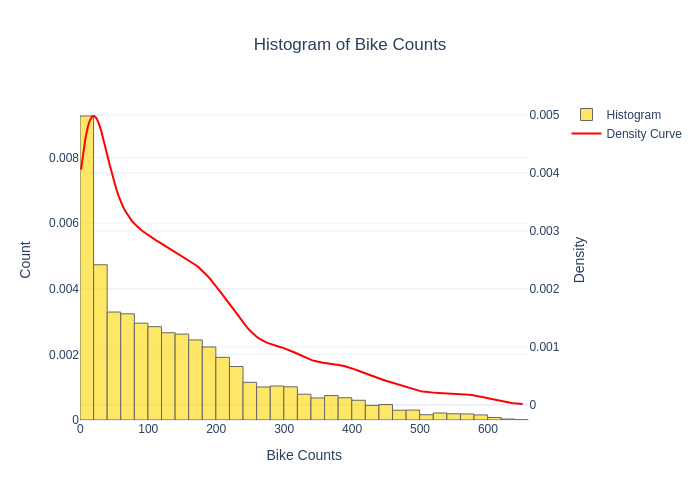

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from scipy import stats

def create_histogram(data, column, title, xaxis_title, yaxis_title="Count", color="gold",
                     opacity=0.6, nbinsx=50, show_density=True):
    """
    Create a histogram with optional density curve

    Parameters:
    data: pandas DataFrame
    column: column name to plot
    title: plot title
    xaxis_title: x-axis title
    yaxis_title: y-axis title
    color: histogram color
    opacity: histogram opacity
    nbinsx: number of bins
    show_density: whether to show density curve
    """

    # Extract data and apply log1p transformation
    values = data[column]

    if show_density:
        # Create subplots with secondary y-axis for density
        fig = make_subplots(specs=[[{"secondary_y": True}]])

        # Add histogram
        fig.add_trace(
            go.Histogram(
                x=values,
                nbinsx=nbinsx,
                name="Histogram",
                marker_color=color,
                marker_line=dict(color='black', width=1),
                opacity=opacity,
                histnorm='probability density'  # Normalize for density comparison
            ),
            secondary_y=False
        )

        # Add density curve
        kde = stats.gaussian_kde(values.dropna())
        x_range = np.linspace(values.min(), values.max(), 200)
        y_density = kde(x_range)

        fig.add_trace(
            go.Scatter(
                x=x_range,
                y=y_density,
                mode='lines',
                name='Density Curve',
                line=dict(color='red', width=2)
            ),
            secondary_y=True
        )

        # Update layout
        fig.update_layout(
            title=dict(text=title, x=0.5),
            xaxis=dict(title=f"{xaxis_title}"),
            yaxis=dict(title=yaxis_title),
            template="plotly_white",
            showlegend=True
        )

        # Set y-axis titles for both sides
        fig.update_yaxes(title_text="Density", secondary_y=True)
        fig.update_yaxes(title_text="Count", secondary_y=False)

    else:
        # Create simple histogram without density curve
        fig = go.Figure()

        fig.add_trace(
            go.Histogram(
                x=values,
                nbinsx=nbinsx,
                marker_color=color,
                marker_line=dict(color='black', width=1),
                opacity=opacity
            )
        )

        fig.update_layout(
            title=dict(text=title, x=0.5),
            xaxis=dict(title=f"log1p({xaxis_title})"),
            yaxis=dict(title=yaxis_title),
            template="plotly_white"
        )

    return fig

# Calories Burned histogram with density curve
fig = create_histogram(
    data=train_ts,
    column="cnt",
    title="Histogram of Bike Counts",
    xaxis_title="Bike Counts",
    color="gold"
)
fig.show()

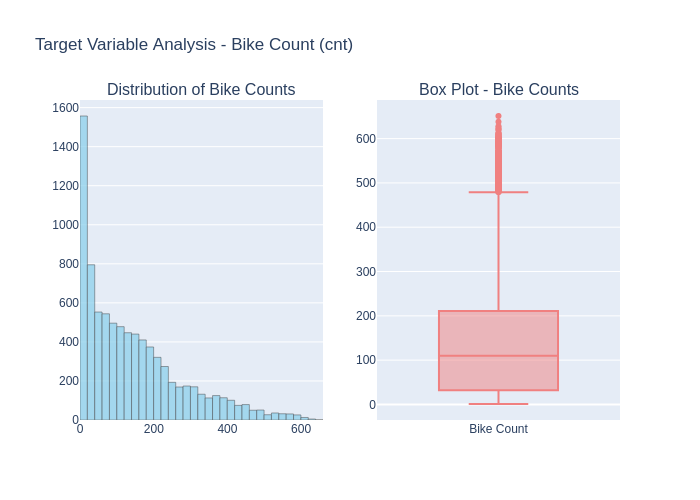

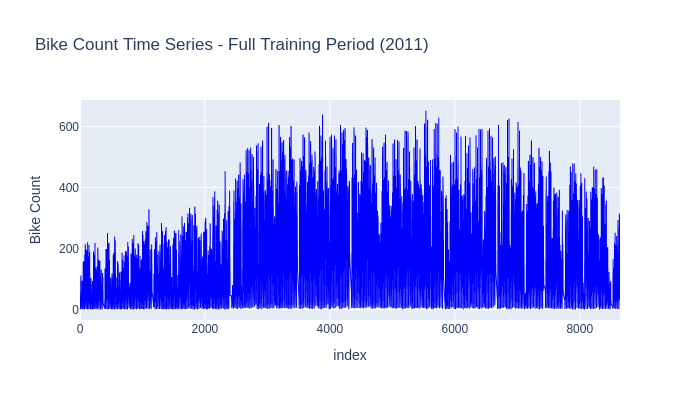

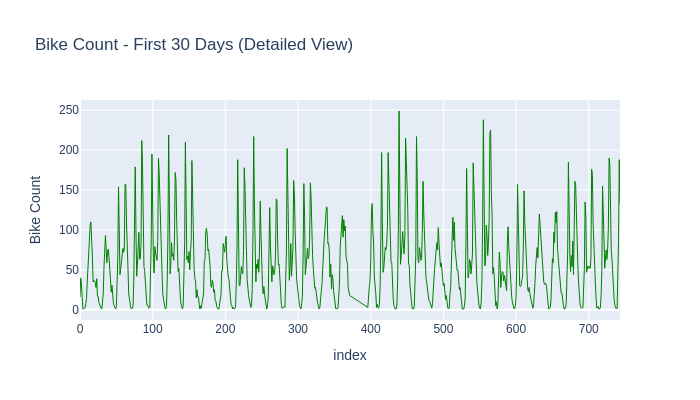

In [32]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

def analyze_target_variable(train_ts):

    # 1. Distribution: Histogram and Boxplot
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Distribution of Bike Counts', 'Box Plot - Bike Counts',
                       'Time Series - Entire Period', 'Time Series - First 30 Days')
        #specs=[[{"colspan": 2}, None], [{"colspan": 2}, None]]
    )

    # Histogram
    fig.add_trace(
        go.Histogram(x=train_ts['cnt'], nbinsx=50, name='Frequency',
                    marker=dict(color='skyblue', line=dict(color='black', width=0.5)), opacity=0.7),
        row=1, col=1
    )

    # Box plot
    fig.add_trace(
        go.Box(y=train_ts['cnt'], name='Bike Count', marker_color='lightcoral'),
        row=1, col=2
    )

    fig.update_layout(
        title_text="Target Variable Analysis - Bike Count (cnt)",
        height=500,
        showlegend=False
    )

    fig.show()

    # 2. Time Series Plots
    # Full timeline
    fig_full = px.line(train_ts, x=train_ts.index, y='cnt',
                      title='Bike Count Time Series - Full Training Period (2011)',
                      labels={'cnt': 'Bike Count', 'datetime': 'Date'})
    fig_full.update_traces(line=dict(width=1, color='blue'))
    fig_full.update_layout(height=400)
    fig_full.show()

    # First 30 days for detailed pattern view
    first_30_days = train_ts.head(24*30)  # First 30 days
    fig_30days = px.line(first_30_days, x=first_30_days.index, y='cnt',
                        title='Bike Count - First 30 Days (Detailed View)',
                        labels={'cnt': 'Bike Count', 'datetime': 'Date'})
    fig_30days.update_traces(line=dict(width=1, color='green'))
    fig_30days.update_layout(height=400)
    fig_30days.show()

    return train_ts['cnt'].describe()

# Execute target variable analysis
target_stats = analyze_target_variable(train_ts)

In [33]:
# Quantitative Variables (numeric and measurable)
quants_new = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

# Summary statistics on 'Quantitative' variables
train_ts_quants = train_ts.loc[:,quants_new]
train_ts_quants.describe()

,temp,atemp,hum,windspeed,cnt
count,8406.000000,8406.000000,8406.000000,8406.000000,8406.000000
mean,0.489738,0.469803,0.644187,0.191162,144.311325
std,0.197871,0.176644,0.196620,0.122883,133.993237
min,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.320000,0.318200,0.490000,0.104500,32.000000
50%,0.500000,0.484800,0.650000,0.194000,110.000000
75%,0.660000,0.621200,0.810000,0.283600,211.000000
max,0.960000,1.000000,1.000000,0.850700,651.000000


* **Time Series** Plots of **Monthly-Bike Count**

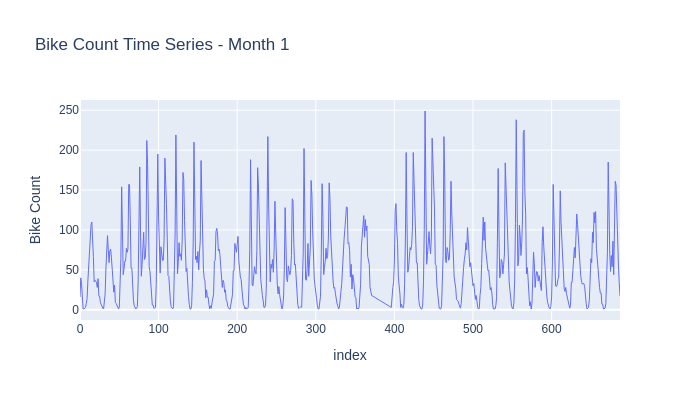

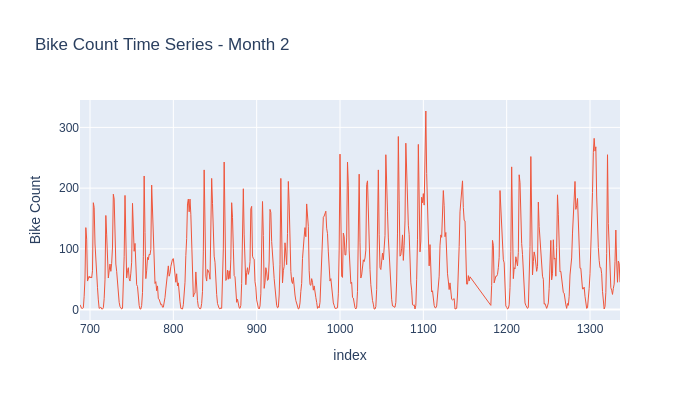

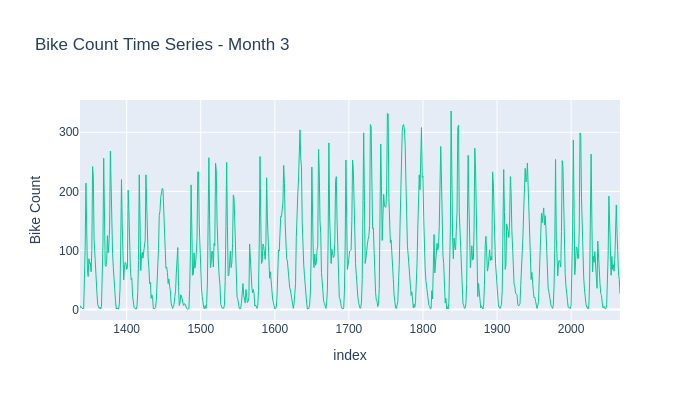

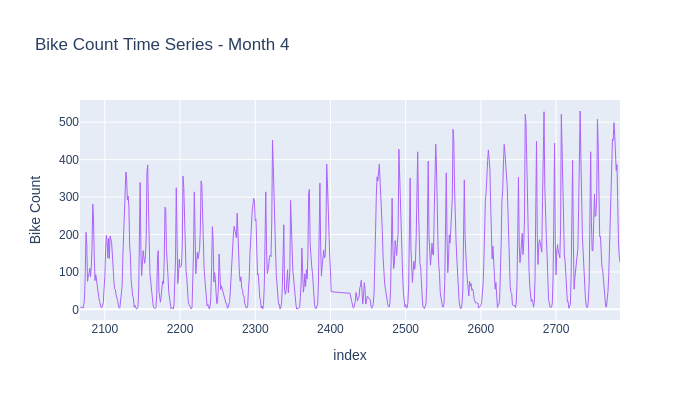

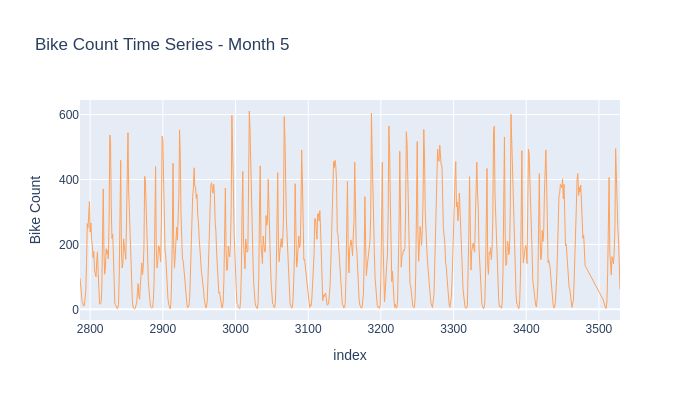

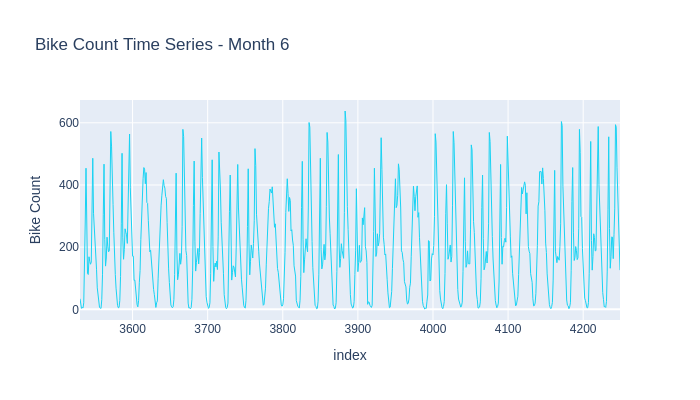

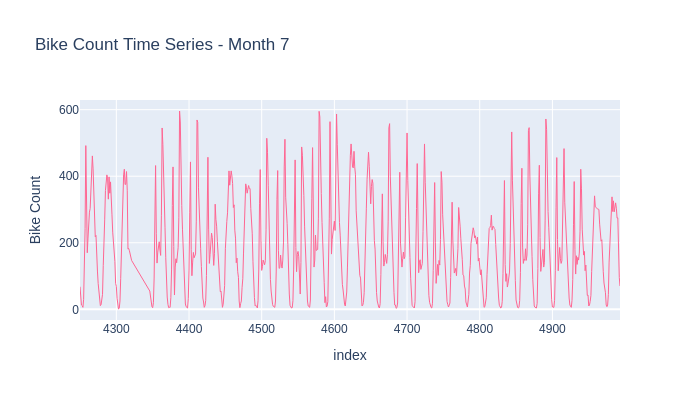

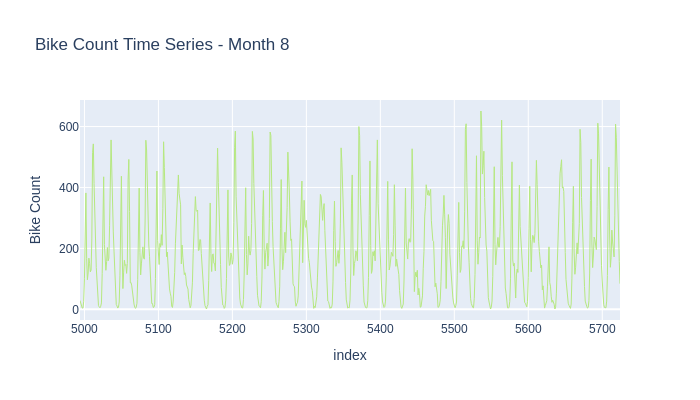

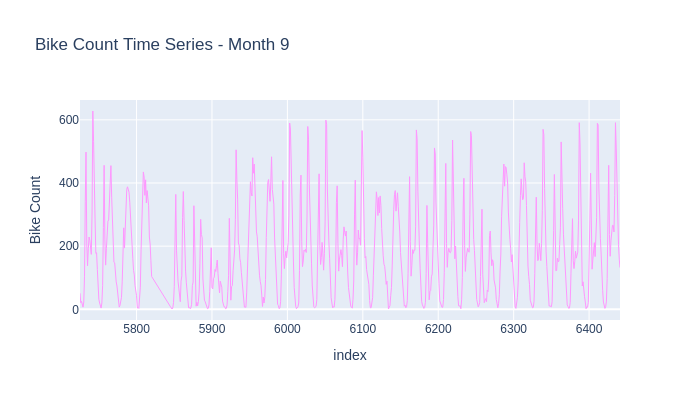

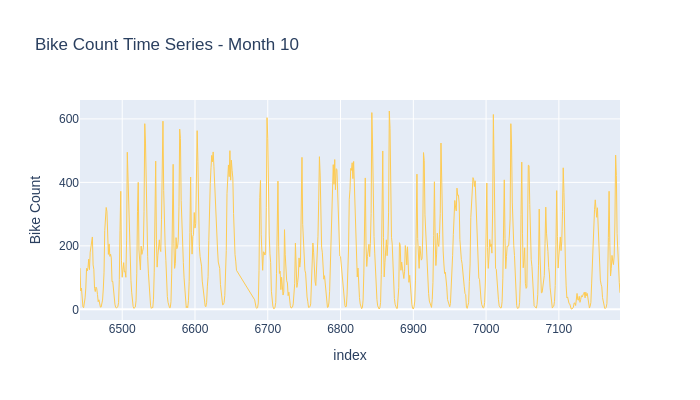

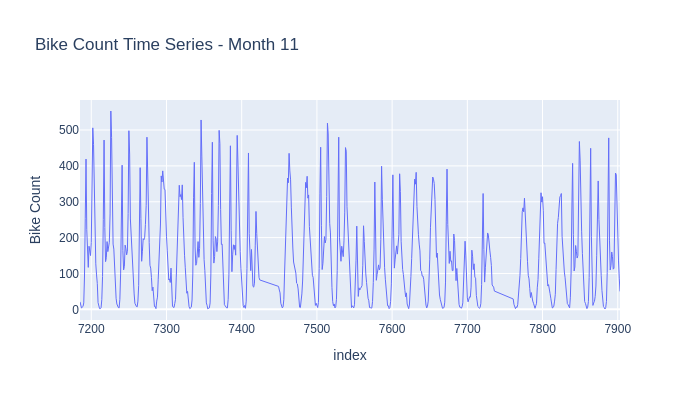

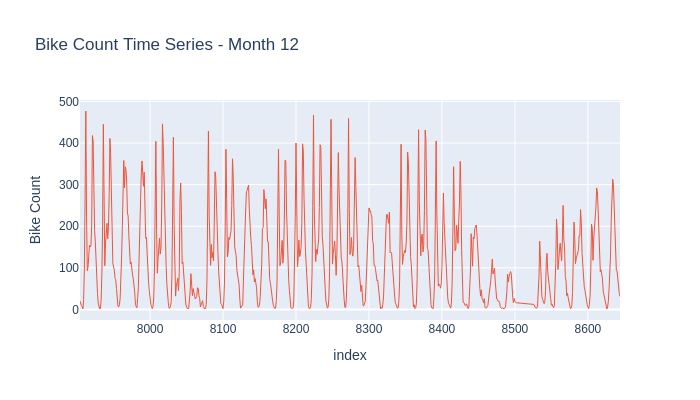

In [34]:
import plotly.express as px

def plot_monthly_time_series_separate(df):
    # Extract month from the datetime index
    #df['month'] = df.index.month

    # Get unique months
    months = sorted(df['month'].unique())

    # Use a color sequence with enough colors for all 12 months
    color_sequence = px.colors.qualitative.Plotly # Using a qualitative color sequence

    # Create and show a plot for each month
    for month in months:
        df_month = df[df['month'] == month]
        # Select a color from the sequence, cycling if necessary
        color = color_sequence[(month - 1) % len(color_sequence)]
        fig = px.line(df_month, x=df_month.index, y='cnt',
                      title=f'Bike Count Time Series - Month {month}',
                      labels={'cnt': 'Bike Count', 'datetime': 'Date'})
        fig.update_traces(line=dict(width=1, color=color))
        fig.update_layout(height=400)
        fig.show()

plot_monthly_time_series_separate(train_ts)



---



**Predictor** Variable Analysis

1. CATEGORICAL VARIABLES ANALYSIS


/tmp/ipykernel_7652/3339568232.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



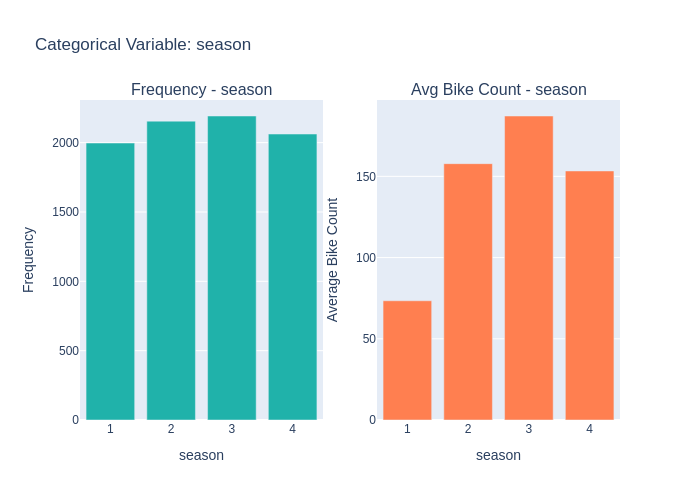


📊 SEASON Summary:
   Categories: 4
   - 1: 1,997 records, Avg bikes: 73.4
   - 2: 2,155 records, Avg bikes: 157.8
   - 3: 2,192 records, Avg bikes: 187.2
   - 4: 2,062 records, Avg bikes: 153.3


/tmp/ipykernel_7652/3339568232.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



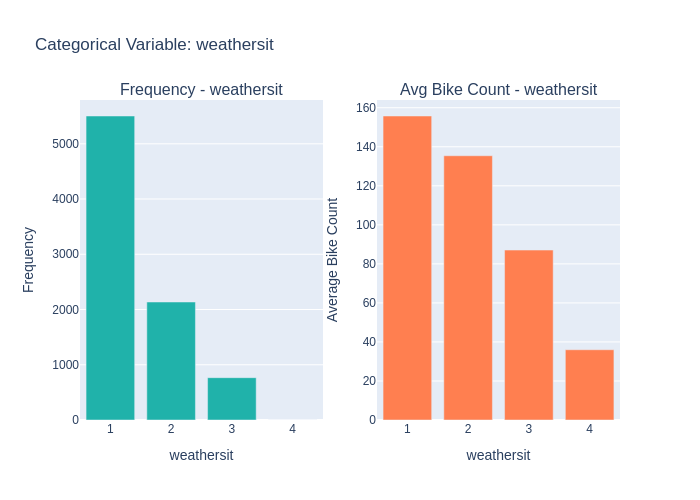


📊 WEATHERSIT Summary:
   Categories: 4
   - 1: 5,503 records, Avg bikes: 155.8
   - 2: 2,136 records, Avg bikes: 135.4
   - 3: 766 records, Avg bikes: 87.1
   - 4: 1 records, Avg bikes: 36.0


/tmp/ipykernel_7652/3339568232.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



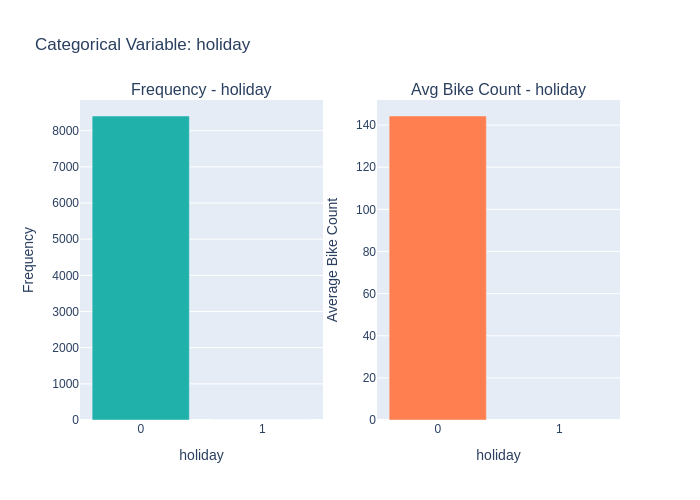


📊 HOLIDAY Summary:
   Categories: 1
   - 0: 8,406 records, Avg bikes: 144.3


/tmp/ipykernel_7652/3339568232.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



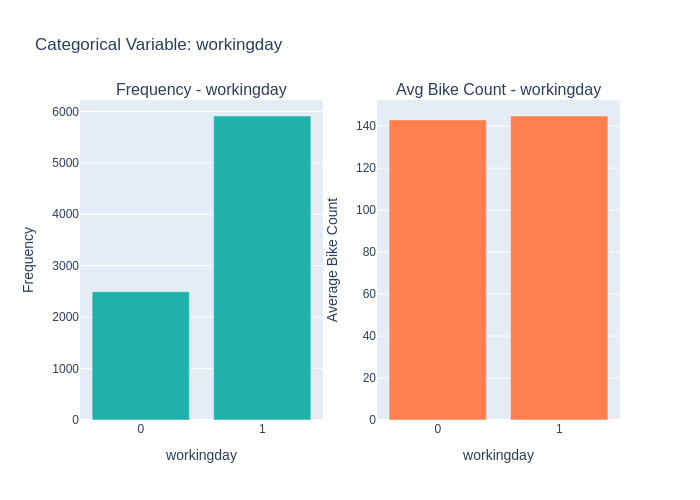


📊 WORKINGDAY Summary:
   Categories: 2
   - 0: 2,495 records, Avg bikes: 143.0
   - 1: 5,911 records, Avg bikes: 144.9


/tmp/ipykernel_7652/3339568232.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



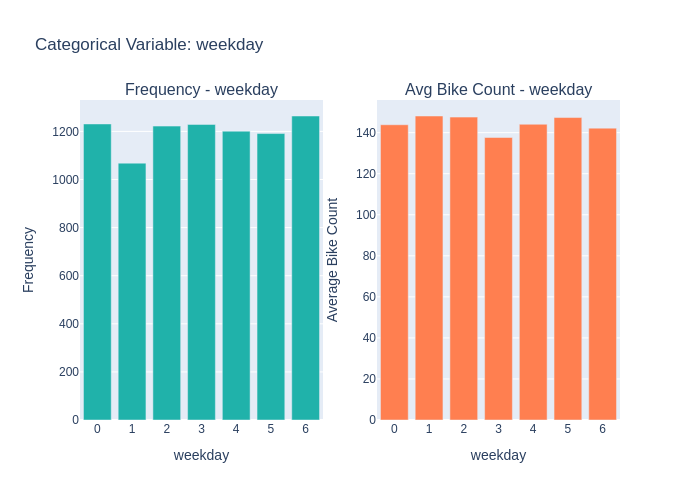


📊 WEEKDAY Summary:
   Categories: 7
   - 0: 1,231 records, Avg bikes: 143.8
   - 1: 1,068 records, Avg bikes: 148.1
   - 2: 1,222 records, Avg bikes: 147.6
   - 3: 1,229 records, Avg bikes: 137.6
   - 4: 1,201 records, Avg bikes: 144.1
   - 5: 1,191 records, Avg bikes: 147.4
   - 6: 1,264 records, Avg bikes: 142.2

2. NUMERICAL VARIABLES ANALYSIS


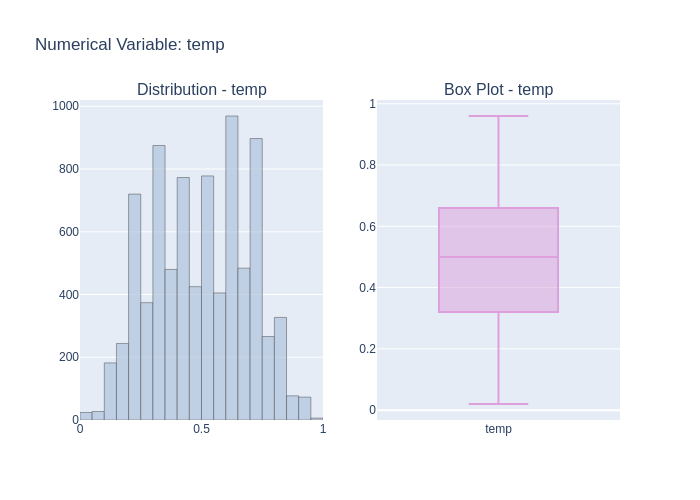


📊 TEMP Summary:
   Mean: 0.4897
   Std:  0.1979
   Min:  0.0200
   Max:  0.9600
   Skew: -0.0292
   Correlation with bike count: 0.4465


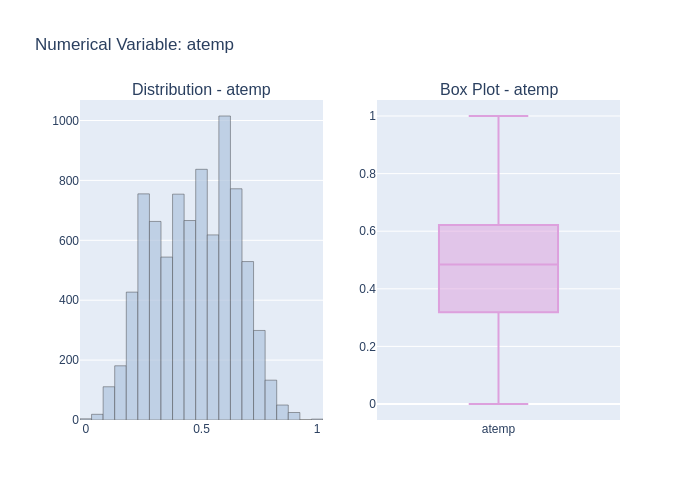


📊 ATEMP Summary:
   Mean: 0.4698
   Std:  0.1766
   Min:  0.0000
   Max:  1.0000
   Skew: -0.0884
   Correlation with bike count: 0.4421


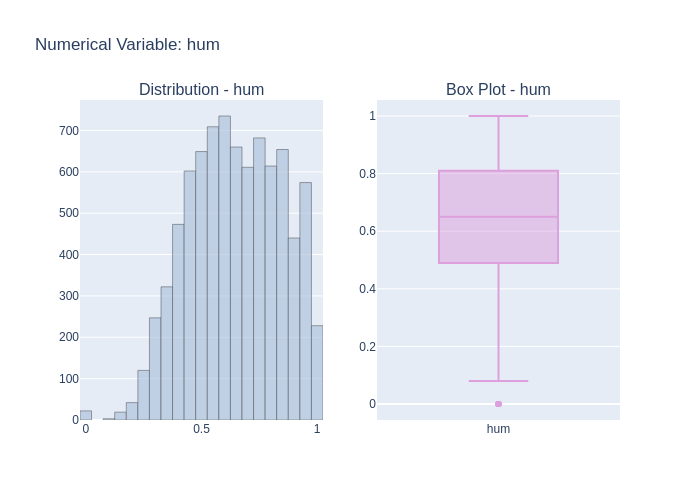


📊 HUM Summary:
   Mean: 0.6442
   Std:  0.1966
   Min:  0.0000
   Max:  1.0000
   Skew: -0.1849
   Correlation with bike count: -0.2896


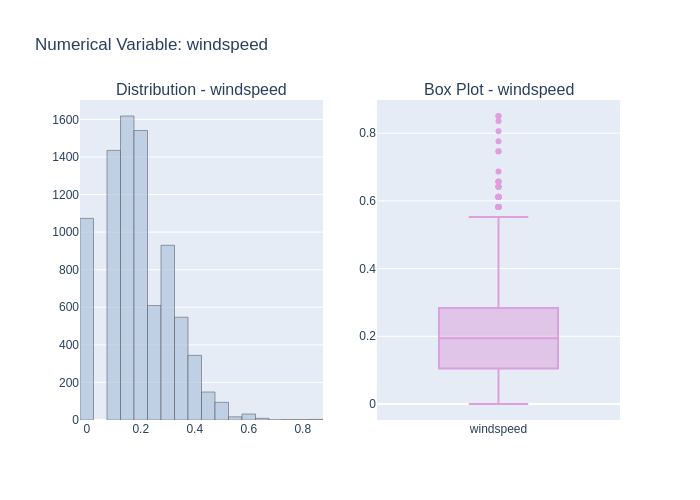


📊 WINDSPEED Summary:
   Mean: 0.1912
   Std:  0.1229
   Min:  0.0000
   Max:  0.8507
   Skew: 0.5447
   Correlation with bike count: 0.0913

3. CYCLICAL VARIABLES ANALYSIS (Hour, Month)


/tmp/ipykernel_7652/3339568232.py:105: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



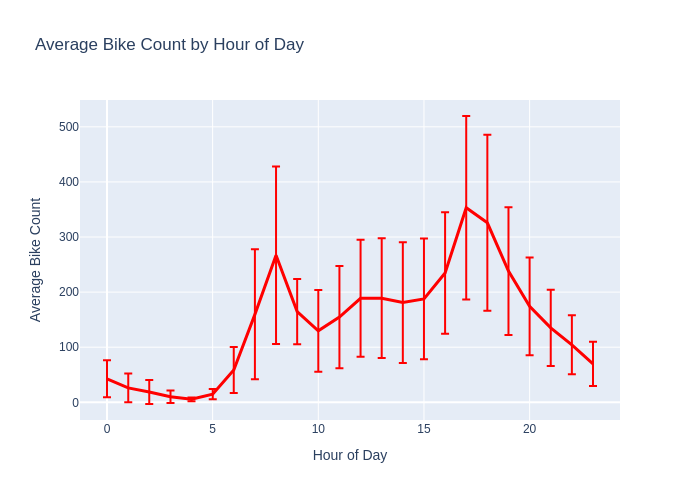

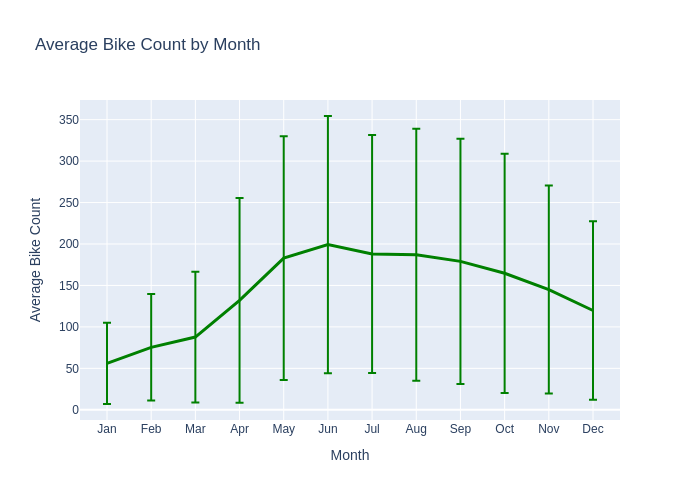


📊 HOURLY PATTERN:
   Peak hour: 17:00 - 353.1 bikes

📊 MONTHLY PATTERN:
   Peak month: Jun - 199.3 bikes


In [35]:
def analyze_predictor_variables(train_ts):

    # Define variables
    categorical_vars = ['season', 'weathersit', 'holiday', 'workingday', 'weekday']
    numerical_vars = ['temp', 'atemp', 'hum', 'windspeed']

    # 1. Categorical Variables Analysis
    print("1. CATEGORICAL VARIABLES ANALYSIS")

    for cat_var in categorical_vars:
        if cat_var in train_ts.columns:
            # Create subplots for frequency and average bike count
            fig = make_subplots(
                rows=1, cols=2,
                subplot_titles=(f'Frequency - {cat_var}', f'Avg Bike Count - {cat_var}'),
                specs=[[{"type": "bar"}, {"type": "bar"}]]
            )

            # Frequency plot
            value_counts = train_ts[cat_var].value_counts().sort_index()
            fig.add_trace(
                go.Bar(x=value_counts.index.astype(str), y=value_counts.values,
                      name='Frequency', marker_color='lightseagreen'),
                row=1, col=1
            )

            # Average bike count per category
            avg_cnt = train_ts.groupby(cat_var)['cnt'].mean().sort_index()
            fig.add_trace(
                go.Bar(x=avg_cnt.index.astype(str), y=avg_cnt.values,
                      name='Avg Bike Count', marker_color='coral'),
                row=1, col=2
            )

            fig.update_layout(
                title_text=f"Categorical Variable: {cat_var}",
                height=500,
                showlegend=False
            )

            fig.update_xaxes(title_text=cat_var, row=1, col=1)
            fig.update_xaxes(title_text=cat_var, row=1, col=2)
            fig.update_yaxes(title_text="Frequency", row=1, col=1)
            fig.update_yaxes(title_text="Average Bike Count", row=1, col=2)

            fig.show()

            # Print summary statistics
            print(f"\n📊 {cat_var.upper()} Summary:")
            print(f"   Categories: {train_ts[cat_var].nunique()}")
            for category in sorted(train_ts[cat_var].unique()):
                category_data = train_ts[train_ts[cat_var] == category]
                print(f"   - {category}: {len(category_data):,} records, "
                      f"Avg bikes: {category_data['cnt'].mean():.1f}")

    # 2. Numerical Variables Analysis
    print("\n2. NUMERICAL VARIABLES ANALYSIS")

    for num_var in numerical_vars:
        if num_var in train_ts.columns:
            # Create distribution plots
            fig = make_subplots(
                rows=1, cols=2,
                subplot_titles=(f'Distribution - {num_var}', f'Box Plot - {num_var}'),
                specs=[[{"type": "histogram"}, {"type": "box"}]]
            )

            # Histogram
            fig.add_trace(
                go.Histogram(x=train_ts[num_var], nbinsx=30, name='Distribution',
                            marker=dict(color='lightsteelblue', line=dict(color='black', width=0.5)), opacity=0.7),
                row=1, col=1
            )

            # Box plot
            fig.add_trace(
                go.Box(y=train_ts[num_var], name=num_var, marker_color='plum'),
                row=1, col=2
            )

            fig.update_layout(
                title_text=f"Numerical Variable: {num_var}",
                height=500,
                showlegend=False
            )

            fig.show()

            # Print statistical summary
            print(f"\n📊 {num_var.upper()} Summary:")
            print(f"   Mean: {train_ts[num_var].mean():.4f}")
            print(f"   Std:  {train_ts[num_var].std():.4f}")
            print(f"   Min:  {train_ts[num_var].min():.4f}")
            print(f"   Max:  {train_ts[num_var].max():.4f}")
            print(f"   Skew: {train_ts[num_var].skew():.4f}")

            # Correlation with target
            correlation = train_ts[num_var].corr(train_ts['cnt'])
            print(f"   Correlation with bike count: {correlation:.4f}")

    # 3. Special Analysis for Cyclical Variables
    print("\n3. CYCLICAL VARIABLES ANALYSIS (Hour, Month)")

    # Hourly pattern
    hourly_pattern = train_ts.groupby('hour')['cnt'].agg(['mean', 'std']).reset_index()
    fig_hour = px.line(hourly_pattern, x='hour', y='mean',
                      error_y='std',
                      title='Average Bike Count by Hour of Day',
                      labels={'hour': 'Hour of Day', 'mean': 'Average Bike Count'})
    fig_hour.update_traces(line=dict(width=3, color='red'))
    fig_hour.update_layout(height=500)
    fig_hour.show()

    # Monthly pattern
    monthly_pattern = train_ts.groupby('month')['cnt'].agg(['mean', 'std']).reset_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_pattern['month_name'] = [month_names[int(i)-1] for i in monthly_pattern['month']]

    fig_month = px.line(monthly_pattern, x='month_name', y='mean',
                       error_y='std',
                       title='Average Bike Count by Month',
                       labels={'month_name': 'Month', 'mean': 'Average Bike Count'})
    fig_month.update_traces(line=dict(width=3, color='green'))
    fig_month.update_layout(height=500)
    fig_month.show()

    # Print cyclical patterns summary
    print(f"\n📊 HOURLY PATTERN:")
    peak_hour = hourly_pattern.loc[hourly_pattern['mean'].idxmax()]
    print(f"   Peak hour: {int(peak_hour['hour']):02d}:00 - {peak_hour['mean']:.1f} bikes")

    print(f"\n📊 MONTHLY PATTERN:")
    peak_month = monthly_pattern.loc[monthly_pattern['mean'].idxmax()]
    print(f"   Peak month: {month_names[int(peak_month['month'])-1]} - {peak_month['mean']:.1f} bikes")

# Execute predictor variables analysis
analyze_predictor_variables(train_ts)



---



Comprehensive **Summary**

In [36]:
def generate_univariate_summary(train_ts):

    # Target variable insights
    cnt_skew = train_ts['cnt'].skew()
    cnt_outliers = len(train_ts[(train_ts['cnt'] > train_ts['cnt'].quantile(0.75) + 1.5*(train_ts['cnt'].quantile(0.75)-train_ts['cnt'].quantile(0.25)))])

    print("🎯 TARGET VARIABLE (cnt) INSIGHTS:")
    print(f"   • Distribution is {'right-skewed' if cnt_skew > 0.5 else 'left-skewed' if cnt_skew < -0.5 else 'approximately normal'} (skewness: {cnt_skew:.3f})")
    print(f"   • Potential outliers: {cnt_outliers} records")
    print(f"   • Range: {train_ts['cnt'].min()} to {train_ts['cnt'].max()} bikes")

    # Categorical variables insights
    print("\n📊 CATEGORICAL VARIABLES INSIGHTS:")
    cat_vars = ['season', 'weathersit', 'holiday', 'workingday']
    for var in cat_vars:
        if var in train_ts.columns:
            most_common = train_ts[var].value_counts().index[0]
            avg_cnt_most_common = train_ts[train_ts[var] == most_common]['cnt'].mean()
            print(f"   • {var}: Most frequent category is {most_common} (avg {avg_cnt_most_common:.1f} bikes)")

    # Numerical variables insights
    print("\n📈 NUMERICAL VARIABLES INSIGHTS:")
    num_vars = ['temp', 'hum', 'windspeed']
    for var in num_vars:
        if var in train_ts.columns:
            corr_with_cnt = train_ts[var].corr(train_ts['cnt'])
            influence = "positive" if corr_with_cnt > 0.1 else "negative" if corr_with_cnt < -0.1 else "weak"
            print(f"   • {var}: {influence} correlation with bike count (r = {corr_with_cnt:.3f})")

    # Cyclical patterns
    print("\n🕒 CYCLICAL PATTERNS:")
    peak_hour = train_ts.groupby('hour')['cnt'].mean().idxmax()
    peak_month = train_ts.groupby('month')['cnt'].mean().idxmax()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    print(f"   • Peak usage hour: {peak_hour:02d}:00")
    print(f"   • Peak usage month: {month_names[peak_month-1]}")
    print(f"   • Weekend vs Weekday ratio: {train_ts[train_ts['workingday']==0]['cnt'].mean()/train_ts[train_ts['workingday']==1]['cnt'].mean():.2f}")

# Generate final summary
generate_univariate_summary(train_ts)

🎯 TARGET VARIABLE (cnt) INSIGHTS:
   • Distribution is right-skewed (skewness: 1.132)
   • Potential outliers: 222 records
   • Range: 1 to 651 bikes

📊 CATEGORICAL VARIABLES INSIGHTS:
   • season: Most frequent category is 3 (avg 187.2 bikes)
   • weathersit: Most frequent category is 1 (avg 155.8 bikes)
   • holiday: Most frequent category is 0 (avg 144.3 bikes)
   • workingday: Most frequent category is 1 (avg 144.9 bikes)

📈 NUMERICAL VARIABLES INSIGHTS:
   • temp: positive correlation with bike count (r = 0.446)
   • hum: negative correlation with bike count (r = -0.290)
   • windspeed: weak correlation with bike count (r = 0.091)

🕒 CYCLICAL PATTERNS:
   • Peak usage hour: 17:00
   • Peak usage month: Jun
   • Weekend vs Weekday ratio: 0.99


/tmp/ipykernel_7652/1117153360.py:32: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.





---



# **Feature Engineering**: Part 2

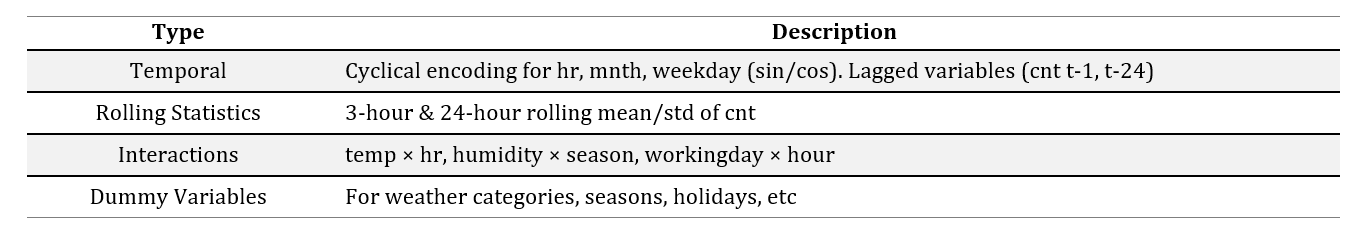

* **Part 1**: **Temporal** Features

In [37]:
def create_temporal_features(df):

    df_engineered = df.copy()

    # Convert categorical time-related columns to numerical types for calculations
    df_engineered['hour'] = df_engineered['hour'].astype(int)
    df_engineered['month'] = df_engineered['month'].astype(int)
    df_engineered['weekday'] = df_engineered['weekday'].astype(int)


    # Cyclical Encoding
    print("CYCLICAL ENCODING...")

    # Hour cyclical encoding (24-hour cycle)
    df_engineered['hour_sin'] = np.sin(2 * np.pi * df_engineered['hour'] / 24)
    df_engineered['hour_cos'] = np.cos(2 * np.pi * df_engineered['hour'] / 24)

    # Month cyclical encoding (12-month cycle)
    df_engineered['month_sin'] = np.sin(2 * np.pi * df_engineered['month'] / 12)
    df_engineered['month_cos'] = np.cos(2 * np.pi * df_engineered['month'] / 12)

    # Weekday cyclical encoding (7-day cycle)
    df_engineered['weekday_sin'] = np.sin(2 * np.pi * df_engineered['weekday'] / 7)
    df_engineered['weekday_cos'] = np.cos(2 * np.pi * df_engineered['weekday'] / 7)


    print("✅ Cyclical encoding completed:")
    print(f"   - Hour: sin({df_engineered['hour_sin'].min():.3f} to {df_engineered['hour_sin'].max():.3f})")
    print(f"   - Hour: cos({df_engineered['hour_cos'].min():.3f} to {df_engineered['hour_cos'].max():.3f})")
    print(f"   - Month: sin({df_engineered['month_sin'].min():.3f} to {df_engineered['month_sin'].max():.3f})")
    print(f"   - Month: cos({df_engineered['month_cos'].min():.3f} to {df_engineered['month_cos'].max():.3f})")
    print(f"   - Weekday: sin({df_engineered['weekday_sin'].min():.3f} to {df_engineered['weekday_sin'].max():.3f})")
    print(f"   - Weekday: cos({df_engineered['weekday_cos'].min():.3f} to {df_engineered['weekday_cos'].max():.3f})")

    return df_engineered

# Create temporal features
print("Training Set....\n")
train_temporal = create_temporal_features(train_ts)

print("\n\nTesting Set....\n")
test_temporal = create_temporal_features(test_ts)

Training Set....

CYCLICAL ENCODING...
✅ Cyclical encoding completed:
   - Hour: sin(-1.000 to 1.000)
   - Hour: cos(-1.000 to 1.000)
   - Month: sin(-1.000 to 1.000)
   - Month: cos(-1.000 to 1.000)
   - Weekday: sin(-0.975 to 0.975)
   - Weekday: cos(-0.901 to 1.000)


Testing Set....

CYCLICAL ENCODING...
✅ Cyclical encoding completed:
   - Hour: sin(-1.000 to 1.000)
   - Hour: cos(-1.000 to 1.000)
   - Month: sin(-1.000 to 1.000)
   - Month: cos(-1.000 to 1.000)
   - Weekday: sin(-0.975 to 0.975)
   - Weekday: cos(-0.901 to 1.000)


**Traininig** Set

In [38]:
train_temporal

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos
0,2011,1,0,1,0,6,0,1,0.24,0.2879,0.81,0.0000,16,0.000000,1.000000,5.000000e-01,0.866025,-0.781831,0.62349
1,2011,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40,0.258819,0.965926,5.000000e-01,0.866025,-0.781831,0.62349
2,2011,1,2,1,0,6,0,1,0.22,0.2727,0.80,0.0000,32,0.500000,0.866025,5.000000e-01,0.866025,-0.781831,0.62349
3,2011,1,3,1,0,6,0,1,0.24,0.2879,0.75,0.0000,13,0.707107,0.707107,5.000000e-01,0.866025,-0.781831,0.62349
4,2011,1,4,1,0,6,0,1,0.24,0.2879,0.75,0.0000,1,0.866025,0.500000,5.000000e-01,0.866025,-0.781831,0.62349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,2011,12,19,1,0,6,0,1,0.42,0.4242,0.54,0.2239,92,-0.965926,0.258819,-2.449294e-16,1.000000,-0.781831,0.62349
8641,2011,12,20,1,0,6,0,1,0.42,0.4242,0.54,0.2239,71,-0.866025,0.500000,-2.449294e-16,1.000000,-0.781831,0.62349
8642,2011,12,21,1,0,6,0,1,0.40,0.4091,0.58,0.1940,52,-0.707107,0.707107,-2.449294e-16,1.000000,-0.781831,0.62349
8643,2011,12,22,1,0,6,0,1,0.38,0.3939,0.62,0.1343,38,-0.500000,0.866025,-2.449294e-16,1.000000,-0.781831,0.62349


**Testing** Set

In [39]:
test_temporal

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos
8645,2012,1,0,1,0,0,0,1,0.36,0.3788,0.66,0.0000,48,0.000000,1.000000,5.000000e-01,0.866025,0.000000,1.00000
8646,2012,1,1,1,0,0,0,1,0.36,0.3485,0.66,0.1343,93,0.258819,0.965926,5.000000e-01,0.866025,0.000000,1.00000
8647,2012,1,2,1,0,0,0,1,0.32,0.3485,0.76,0.0000,75,0.500000,0.866025,5.000000e-01,0.866025,0.000000,1.00000
8648,2012,1,3,1,0,0,0,1,0.30,0.3333,0.81,0.0000,52,0.707107,0.707107,5.000000e-01,0.866025,0.000000,1.00000
8649,2012,1,4,1,0,0,0,1,0.28,0.3030,0.81,0.0896,8,0.866025,0.500000,5.000000e-01,0.866025,0.000000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012,12,19,1,0,1,1,2,0.26,0.2576,0.60,0.1642,119,-0.965926,0.258819,-2.449294e-16,1.000000,0.781831,0.62349
17375,2012,12,20,1,0,1,1,2,0.26,0.2576,0.60,0.1642,89,-0.866025,0.500000,-2.449294e-16,1.000000,0.781831,0.62349
17376,2012,12,21,1,0,1,1,1,0.26,0.2576,0.60,0.1642,90,-0.707107,0.707107,-2.449294e-16,1.000000,0.781831,0.62349
17377,2012,12,22,1,0,1,1,1,0.26,0.2727,0.56,0.1343,61,-0.500000,0.866025,-2.449294e-16,1.000000,0.781831,0.62349




---



* **Part 2**: **Lag** Features

In [40]:
def create_lag_features(df):

    df_lagged = df.copy()

    # Ensure the data is sorted by datetime
    df_lagged = df_lagged.sort_index()

    # 1. Short-term lags (previous hours)
    print("1. SHORT-TERM LAGS")
    df_lagged['lag_1h'] = df_lagged['cnt'].shift(1)
    df_lagged['lag_2h'] = df_lagged['cnt'].shift(2)
    df_lagged['lag_3h'] = df_lagged['cnt'].shift(3)

    # 2. Daily lags (same hour previous days)
    print("2. DAILY LAGS")
    df_lagged['lag_24h'] = df_lagged['cnt'].shift(24)    # Previous day same hour
    df_lagged['lag_48h'] = df_lagged['cnt'].shift(48)    # 2 days ago same hour
    df_lagged['lag_72h'] = df_lagged['cnt'].shift(72)    # 3 days ago same hour

    # 3. Weekly lags (same hour, same day of previous week)
    print("3. WEEKLY LAGS")
    df_lagged['lag_168h'] = df_lagged['cnt'].shift(168)  # Previous week same hour/day

    # Count NaN values introduced by lag features
    lag_columns = ['lag_1h', 'lag_24h', 'lag_168h']
    nan_counts = {col: df_lagged[col].isna().sum() for col in lag_columns}

    print("✅ Lag features created:")
    for col, nan_count in nan_counts.items():
        print(f"   - {col}: {nan_count:,} NaN values ({nan_count/len(df_lagged)*100:.1f}%)")

    print(f"\n📊 LAG FEATURE SUMMARY:")
    print(f"   Total lag features added: {len([col for col in df_lagged.columns if 'lag' in col or 'diff' in col or 'pct_change' in col])}")
    print(f"   New dataset shape: {df_lagged.shape}")

    return df_lagged

# Create lag features
print("Training Set....\n")
train_lagged = create_lag_features(train_temporal)

print("\n\nTesting Set....\n")
test_lagged = create_lag_features(test_temporal)

Training Set....

1. SHORT-TERM LAGS
2. DAILY LAGS
3. WEEKLY LAGS
✅ Lag features created:
   - lag_1h: 1 NaN values (0.0%)
   - lag_24h: 24 NaN values (0.3%)
   - lag_168h: 168 NaN values (2.0%)

📊 LAG FEATURE SUMMARY:
   Total lag features added: 7
   New dataset shape: (8406, 26)


Testing Set....

1. SHORT-TERM LAGS
2. DAILY LAGS
3. WEEKLY LAGS
✅ Lag features created:
   - lag_1h: 1 NaN values (0.0%)
   - lag_24h: 24 NaN values (0.3%)
   - lag_168h: 168 NaN values (2.0%)

📊 LAG FEATURE SUMMARY:
   Total lag features added: 7
   New dataset shape: (8449, 26)


**Traininig** Set

In [41]:
train_lagged

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,month_cos,weekday_sin,weekday_cos,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,lag_72h,lag_168h
0,2011,1,0,1,0,6,0,1,0.24,0.2879,...,0.866025,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,1,1,1,0,6,0,1,0.22,0.2727,...,0.866025,-0.781831,0.62349,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,1,2,1,0,6,0,1,0.22,0.2727,...,0.866025,-0.781831,0.62349,40.0,16.0,NaN,NaN,NaN,NaN,NaN
3,2011,1,3,1,0,6,0,1,0.24,0.2879,...,0.866025,-0.781831,0.62349,32.0,40.0,16.0,NaN,NaN,NaN,NaN
4,2011,1,4,1,0,6,0,1,0.24,0.2879,...,0.866025,-0.781831,0.62349,13.0,32.0,40.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,2011,12,19,1,0,6,0,1,0.42,0.4242,...,1.000000,-0.781831,0.62349,93.0,129.0,195.0,112.0,135.0,151.0,140.0
8641,2011,12,20,1,0,6,0,1,0.42,0.4242,...,1.000000,-0.781831,0.62349,92.0,93.0,129.0,91.0,96.0,79.0,95.0
8642,2011,12,21,1,0,6,0,1,0.40,0.4091,...,1.000000,-0.781831,0.62349,71.0,92.0,93.0,95.0,68.0,70.0,76.0
8643,2011,12,22,1,0,6,0,1,0.38,0.3939,...,1.000000,-0.781831,0.62349,52.0,71.0,92.0,85.0,55.0,33.0,50.0


**Testing** Set

In [42]:
test_lagged

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,month_cos,weekday_sin,weekday_cos,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,lag_72h,lag_168h
8645,2012,1,0,1,0,0,0,1,0.36,0.3788,...,0.866025,0.000000,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8646,2012,1,1,1,0,0,0,1,0.36,0.3485,...,0.866025,0.000000,1.00000,48.0,NaN,NaN,NaN,NaN,NaN,NaN
8647,2012,1,2,1,0,0,0,1,0.32,0.3485,...,0.866025,0.000000,1.00000,93.0,48.0,NaN,NaN,NaN,NaN,NaN
8648,2012,1,3,1,0,0,0,1,0.30,0.3333,...,0.866025,0.000000,1.00000,75.0,93.0,48.0,NaN,NaN,NaN,NaN
8649,2012,1,4,1,0,0,0,1,0.28,0.3030,...,0.866025,0.000000,1.00000,52.0,75.0,93.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012,12,19,1,0,1,1,2,0.26,0.2576,...,1.000000,0.781831,0.62349,122.0,164.0,214.0,102.0,97.0,128.0,93.0
17375,2012,12,20,1,0,1,1,2,0.26,0.2576,...,1.000000,0.781831,0.62349,119.0,122.0,164.0,72.0,66.0,97.0,58.0
17376,2012,12,21,1,0,1,1,1,0.26,0.2576,...,1.000000,0.781831,0.62349,89.0,119.0,122.0,47.0,60.0,92.0,52.0
17377,2012,12,22,1,0,1,1,1,0.26,0.2727,...,1.000000,0.781831,0.62349,90.0,89.0,119.0,36.0,54.0,62.0,42.0




---



* **Part 3**: **Rolling Window** Statistics

In [43]:
def create_rolling_features(df):

    df_rolling = df.copy()

    # Ensure the data is sorted by datetime
    df_rolling = df_rolling.sort_index()

    # 1. Short-term rolling statistics (hours)
    print("1. SHORT-TERM ROLLING STATISTICS")
    df_rolling['rolling_mean_3h'] = df_rolling['cnt'].rolling(window=3, center=True, min_periods=1).mean()
    df_rolling['rolling_std_3h'] = df_rolling['cnt'].rolling(window=3, center=True, min_periods=1).std()
    df_rolling['rolling_min_3h'] = df_rolling['cnt'].rolling(window=3, center=True, min_periods=1).min()
    df_rolling['rolling_max_3h'] = df_rolling['cnt'].rolling(window=3, center=True, min_periods=1).max()

    # 2. Medium-term rolling statistics (hours)
    print("2. MEDIUM-TERM ROLLING STATISTICS")
    df_rolling['rolling_mean_6h'] = df_rolling['cnt'].rolling(window=6, center=True, min_periods=1).mean()
    df_rolling['rolling_std_6h'] = df_rolling['cnt'].rolling(window=6, center=True, min_periods=1).std()
    df_rolling['rolling_mean_12h'] = df_rolling['cnt'].rolling(window=12, center=True, min_periods=1).mean()
    df_rolling['rolling_std_12h'] = df_rolling['cnt'].rolling(window=12, center=True, min_periods=1).std()

    # 3. Daily rolling statistics
    print("3. DAILY ROLLING STATISTICS")
    df_rolling['rolling_mean_24h'] = df_rolling['cnt'].rolling(window=24, center=True, min_periods=1).mean()
    df_rolling['rolling_std_24h'] = df_rolling['cnt'].rolling(window=24, center=True, min_periods=1).std()

    # 4. Weekly rolling statistics
    print("4. WEEKLY ROLLING STATISTICS")
    df_rolling['rolling_mean_168h'] = df_rolling['cnt'].rolling(window=168, center=True, min_periods=1).mean()
    df_rolling['rolling_std_168h'] = df_rolling['cnt'].rolling(window=168, center=True, min_periods=1).std()

    # Count NaN values introduced by rolling features
    rolling_columns = ['rolling_mean_3h', 'rolling_std_24h']
    nan_counts = {col: df_rolling[col].isna().sum() for col in rolling_columns}

    print("✅ Rolling features created:")
    for col, nan_count in nan_counts.items():
        if nan_count > 0:
            print(f"   - {col}: {nan_count:,} NaN values ({nan_count/len(df_rolling)*100:.1f}%)")
        else:
            print(f"   - {col}: No NaN values (used min_periods=1)")

    print(f"\n📊 ROLLING FEATURES SUMMARY:")
    rolling_feature_count = len([col for col in df_rolling.columns if 'rolling' in col or 'ema' in col or 'z_score' in col or 'pct_deviation' in col])
    print(f"   Total rolling features added: {rolling_feature_count}")
    print(f"   New dataset shape: {df_rolling.shape}")

    return df_rolling


# Create rolling features
print("Training Set....\n")
train_rolling = create_rolling_features(train_lagged)

print("\n\nTesting Set....\n")
test_rolling = create_rolling_features(test_lagged)

Training Set....

1. SHORT-TERM ROLLING STATISTICS
2. MEDIUM-TERM ROLLING STATISTICS
3. DAILY ROLLING STATISTICS
4. WEEKLY ROLLING STATISTICS
✅ Rolling features created:
   - rolling_mean_3h: No NaN values (used min_periods=1)
   - rolling_std_24h: No NaN values (used min_periods=1)

📊 ROLLING FEATURES SUMMARY:
   Total rolling features added: 12
   New dataset shape: (8406, 38)


Testing Set....

1. SHORT-TERM ROLLING STATISTICS
2. MEDIUM-TERM ROLLING STATISTICS
3. DAILY ROLLING STATISTICS
4. WEEKLY ROLLING STATISTICS
✅ Rolling features created:
   - rolling_mean_3h: No NaN values (used min_periods=1)
   - rolling_std_24h: No NaN values (used min_periods=1)

📊 ROLLING FEATURES SUMMARY:
   Total rolling features added: 12
   New dataset shape: (8449, 38)


**Traininig** Set

In [44]:
train_rolling

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_min_3h,rolling_max_3h,rolling_mean_6h,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h
0,2011,1,0,1,0,6,0,1,0.24,0.2879,...,16.0,40.0,29.333333,12.220202,17.166667,16.017699,18.500000,18.213382,47.142857,41.338492
1,2011,1,1,1,0,6,0,1,0.22,0.2727,...,16.0,40.0,25.250000,12.893797,15.000000,15.705625,23.538462,25.181393,47.564706,41.275338
2,2011,1,2,1,0,6,0,1,0.22,0.2727,...,13.0,40.0,20.400000,15.565989,13.500000,15.146900,28.571429,30.658703,49.476744,44.699185
3,2011,1,3,1,0,6,0,1,0.24,0.2879,...,1.0,32.0,17.166667,16.017699,12.888889,14.286746,33.733333,35.672051,51.000000,46.654594
4,2011,1,4,1,0,6,0,1,0.24,0.2879,...,1.0,13.0,14.833333,17.197868,13.000000,13.474255,38.500000,39.385276,51.693182,46.839260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,2011,12,19,1,0,6,0,1,0.42,0.4242,...,71.0,93.0,105.333333,50.898592,142.454545,105.204908,137.823529,99.953261,113.752809,84.243192
8641,2011,12,20,1,0,6,0,1,0.42,0.4242,...,52.0,92.0,79.166667,32.676699,125.400000,93.503654,145.250000,98.268001,113.795455,84.724999
8642,2011,12,21,1,0,6,0,1,0.40,0.4091,...,38.0,71.0,62.833333,26.738861,106.000000,74.844840,151.666667,98.186169,112.609195,84.477926
8643,2011,12,22,1,0,6,0,1,0.38,0.3939,...,31.0,52.0,56.800000,24.913852,87.625000,54.121391,156.071429,100.342846,111.720930,84.563746


**Testing** Set

In [45]:
test_rolling

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_min_3h,rolling_max_3h,rolling_mean_6h,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h
8645,2012,1,0,1,0,0,0,1,0.36,0.3788,...,48.0,93.0,72.000000,22.649503,46.833333,35.244385,46.000000,42.396398,95.642857,91.841881
8646,2012,1,1,1,0,0,0,1,0.36,0.3485,...,48.0,93.0,67.000000,21.023796,40.428571,36.363247,57.923077,59.124814,95.929412,91.331785
8647,2012,1,2,1,0,0,0,1,0.32,0.3485,...,52.0,93.0,55.200000,32.057760,36.250000,35.680127,69.714286,71.925633,96.186047,90.824137
8648,2012,1,3,1,0,0,0,1,0.30,0.3333,...,8.0,75.0,46.833333,35.244385,33.777778,34.189830,82.866667,86.014838,96.425287,90.322115
8649,2012,1,4,1,0,0,0,1,0.28,0.3030,...,5.0,52.0,39.166667,39.665686,34.400000,32.294478,94.250000,94.755475,96.681818,89.833760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012,12,19,1,0,1,1,2,0.26,0.2576,...,89.0,122.0,133.000000,48.216180,152.090909,84.187237,153.647059,72.246056,99.438202,77.971288
17375,2012,12,20,1,0,1,1,2,0.26,0.2576,...,89.0,119.0,107.500000,35.624430,147.000000,86.938037,157.937500,72.344056,99.295455,78.406421
17376,2012,12,21,1,0,1,1,1,0.26,0.2576,...,61.0,90.0,88.333333,29.568001,135.888889,84.345190,155.400000,74.142527,97.689655,77.391832
17377,2012,12,22,1,0,1,1,1,0.26,0.2727,...,49.0,90.0,81.600000,27.437201,113.500000,54.539632,155.285714,76.939965,96.604651,77.177302




---



* **Part 4**: **Interaction** Features

In [46]:
def create_interaction_features(df):

    df_interaction = df.copy()

    # Convert categorical columns used in calculations to numerical types
    categorical_cols_to_convert = ['season', 'hour', 'workingday']
    for col in categorical_cols_to_convert:
        if col in df_interaction.columns:
            df_interaction[col] = df_interaction[col].astype(int)


    # 1. Weather-time interactions
    print("1. WEATHER-TIME INTERACTIONS")
    df_interaction['temp_x_workingday'] = df_interaction['temp'] * df_interaction['workingday']

    # 2. Temperature-season interactions
    print("2. TEMPERATURE-SEASON INTERACTIONS")
    df_interaction['temp_x_season'] = df_interaction['temp'] * df_interaction['season']

    # 3. Temperature-time interactions
    print("3. TEMPERATURE-TIME INTERACTIONS")
    df_interaction['temp_x_hour'] = df_interaction['temp'] * df_interaction['hour']

    print("✅ Interaction features created:")
    interaction_columns = [
        'temp_x_workingday', 'temp_x_season', 'temp_x_hour'
    ]

    for col in interaction_columns:
        if col in df_interaction.columns:
            unique_vals = df_interaction[col].nunique()
            print(f"   - {col}: {unique_vals} unique values")

    # Final feature count summary
    original_features = len(df.columns)
    final_features = len(df_interaction.columns)
    features_added = final_features - original_features

    print(f"\n🎯 FEATURE ENGINEERING COMPLETE SUMMARY:")
    print(f"   Original features: {original_features}")
    print(f"   Final features: {final_features}")
    print(f"   Features added: {features_added}")
    print(f"   Feature expansion: {(final_features/original_features-1)*100:.1f}% increase")

    return df_interaction

# Create interaction features
print("Training Set....\n")
train_final = create_interaction_features(train_rolling)

print("\n\nTesting Set....\n")
test_final = create_interaction_features(test_rolling)

Training Set....

1. WEATHER-TIME INTERACTIONS
2. TEMPERATURE-SEASON INTERACTIONS
3. TEMPERATURE-TIME INTERACTIONS
✅ Interaction features created:
   - temp_x_workingday: 49 unique values
   - temp_x_season: 101 unique values
   - temp_x_hour: 506 unique values

🎯 FEATURE ENGINEERING COMPLETE SUMMARY:
   Original features: 38
   Final features: 41
   Features added: 3
   Feature expansion: 7.9% increase


Testing Set....

1. WEATHER-TIME INTERACTIONS
2. TEMPERATURE-SEASON INTERACTIONS
3. TEMPERATURE-TIME INTERACTIONS
✅ Interaction features created:
   - temp_x_workingday: 50 unique values
   - temp_x_season: 101 unique values
   - temp_x_hour: 510 unique values

🎯 FEATURE ENGINEERING COMPLETE SUMMARY:
   Original features: 38
   Final features: 41
   Features added: 3
   Feature expansion: 7.9% increase


**Traininig** Set

In [47]:
train_final

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour
0,2011,1,0,1,0,6,0,1,0.24,0.2879,...,12.220202,17.166667,16.017699,18.500000,18.213382,47.142857,41.338492,0.0,0.24,0.00
1,2011,1,1,1,0,6,0,1,0.22,0.2727,...,12.893797,15.000000,15.705625,23.538462,25.181393,47.564706,41.275338,0.0,0.22,0.22
2,2011,1,2,1,0,6,0,1,0.22,0.2727,...,15.565989,13.500000,15.146900,28.571429,30.658703,49.476744,44.699185,0.0,0.22,0.44
3,2011,1,3,1,0,6,0,1,0.24,0.2879,...,16.017699,12.888889,14.286746,33.733333,35.672051,51.000000,46.654594,0.0,0.24,0.72
4,2011,1,4,1,0,6,0,1,0.24,0.2879,...,17.197868,13.000000,13.474255,38.500000,39.385276,51.693182,46.839260,0.0,0.24,0.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,2011,12,19,1,0,6,0,1,0.42,0.4242,...,50.898592,142.454545,105.204908,137.823529,99.953261,113.752809,84.243192,0.0,0.42,7.98
8641,2011,12,20,1,0,6,0,1,0.42,0.4242,...,32.676699,125.400000,93.503654,145.250000,98.268001,113.795455,84.724999,0.0,0.42,8.40
8642,2011,12,21,1,0,6,0,1,0.40,0.4091,...,26.738861,106.000000,74.844840,151.666667,98.186169,112.609195,84.477926,0.0,0.40,8.40
8643,2011,12,22,1,0,6,0,1,0.38,0.3939,...,24.913852,87.625000,54.121391,156.071429,100.342846,111.720930,84.563746,0.0,0.38,8.36


In [48]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8406 entries, 0 to 8644
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               8406 non-null   int32   
 1   month              8406 non-null   int64   
 2   hour               8406 non-null   int64   
 3   season             8406 non-null   int64   
 4   holiday            8406 non-null   category
 5   weekday            8406 non-null   int64   
 6   workingday         8406 non-null   int64   
 7   weathersit         8406 non-null   category
 8   temp               8406 non-null   float64 
 9   atemp              8406 non-null   float64 
 10  hum                8406 non-null   float64 
 11  windspeed          8406 non-null   float64 
 12  cnt                8406 non-null   int64   
 13  hour_sin           8406 non-null   float64 
 14  hour_cos           8406 non-null   float64 
 15  month_sin          8406 non-null   float64 
 16  month_cos  

**Testing** Set

In [49]:
test_final

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour
8645,2012,1,0,1,0,0,0,1,0.36,0.3788,...,22.649503,46.833333,35.244385,46.000000,42.396398,95.642857,91.841881,0.00,0.36,0.00
8646,2012,1,1,1,0,0,0,1,0.36,0.3485,...,21.023796,40.428571,36.363247,57.923077,59.124814,95.929412,91.331785,0.00,0.36,0.36
8647,2012,1,2,1,0,0,0,1,0.32,0.3485,...,32.057760,36.250000,35.680127,69.714286,71.925633,96.186047,90.824137,0.00,0.32,0.64
8648,2012,1,3,1,0,0,0,1,0.30,0.3333,...,35.244385,33.777778,34.189830,82.866667,86.014838,96.425287,90.322115,0.00,0.30,0.90
8649,2012,1,4,1,0,0,0,1,0.28,0.3030,...,39.665686,34.400000,32.294478,94.250000,94.755475,96.681818,89.833760,0.00,0.28,1.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012,12,19,1,0,1,1,2,0.26,0.2576,...,48.216180,152.090909,84.187237,153.647059,72.246056,99.438202,77.971288,0.26,0.26,4.94
17375,2012,12,20,1,0,1,1,2,0.26,0.2576,...,35.624430,147.000000,86.938037,157.937500,72.344056,99.295455,78.406421,0.26,0.26,5.20
17376,2012,12,21,1,0,1,1,1,0.26,0.2576,...,29.568001,135.888889,84.345190,155.400000,74.142527,97.689655,77.391832,0.26,0.26,5.46
17377,2012,12,22,1,0,1,1,1,0.26,0.2727,...,27.437201,113.500000,54.539632,155.285714,76.939965,96.604651,77.177302,0.26,0.26,5.72


In [50]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8449 entries, 8645 to 17378
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               8449 non-null   int32   
 1   month              8449 non-null   int64   
 2   hour               8449 non-null   int64   
 3   season             8449 non-null   int64   
 4   holiday            8449 non-null   category
 5   weekday            8449 non-null   int64   
 6   workingday         8449 non-null   int64   
 7   weathersit         8449 non-null   category
 8   temp               8449 non-null   float64 
 9   atemp              8449 non-null   float64 
 10  hum                8449 non-null   float64 
 11  windspeed          8449 non-null   float64 
 12  cnt                8449 non-null   int64   
 13  hour_sin           8449 non-null   float64 
 14  hour_cos           8449 non-null   float64 
 15  month_sin          8449 non-null   float64 
 16  month_c



---



* Feature **Summary**

In [51]:
def feature_engineering_summary(df):

    feature_categories = {
        'Temporal Features': [col for col in df.columns if 'sin' in col or 'cos' in col or 'is_' in col and 'lag' not in col and 'rolling' not in col],
        'Lag Features': [col for col in df.columns if 'lag' in col or 'diff' in col or 'pct_change' in col],
        'Rolling Features': [col for col in df.columns if 'rolling' in col or 'ema' in col or 'z_score' in col or 'pct_deviation' in col],
        'Interaction Features': [col for col in df.columns if '_x_' in col or 'good_weather' in col or 'bad_weather' in col or 'unexpected' in col],
        'Polynomial/Ratio Features': [col for col in df.columns if 'squared' in col or 'ratio' in col]
    }

    print("📊 FEATURE CATEGORIES BREAKDOWN:")
    total_engineered = 0
    for category, features in feature_categories.items():
        count = len(features)
        total_engineered += count
        print(f"   {category}: {count} features")
        if features:
            print(f"      Examples: {features[:3]}")  # Show first 3 examples

    print(f"\n🎯 FINAL DATASET INFO:")
    print(f"   Total features: {len(df.columns)}")
    print(f"   Engineered features: {total_engineered}")
    print(f"   Original features: {len(df.columns) - total_engineered}")
    print(f"   Total records: {len(df):,}")

    # Check for missing values in engineered features
    print(f"\n🔍 DATA QUALITY CHECK:")
    engineered_cols = [col for category in feature_categories.values() for col in category]
    missing_counts = df[engineered_cols].isnull().sum()

    high_missing = missing_counts[missing_counts > 0]
    if len(high_missing) > 0:
        print("   Features with missing values:")
        for col, count in high_missing.items():
            print(f"      {col}: {count:,} missing ({count/len(df)*100:.1f}%)")
    else:
        print("   ✅ No missing values in engineered features")

    return feature_categories

# Generate final summary
print("Training Set....\n")
train_feature_categories = feature_engineering_summary(train_final)

print("\n\nTesting Set....\n")
test_feature_categories = feature_engineering_summary(test_final)

Training Set....

📊 FEATURE CATEGORIES BREAKDOWN:
   Temporal Features: 6 features
      Examples: ['hour_sin', 'hour_cos', 'month_sin']
   Lag Features: 7 features
      Examples: ['lag_1h', 'lag_2h', 'lag_3h']
   Rolling Features: 12 features
      Examples: ['rolling_mean_3h', 'rolling_std_3h', 'rolling_min_3h']
   Interaction Features: 3 features
      Examples: ['temp_x_workingday', 'temp_x_season', 'temp_x_hour']
   Polynomial/Ratio Features: 0 features

🎯 FINAL DATASET INFO:
   Total features: 41
   Engineered features: 28
   Original features: 13
   Total records: 8,406

🔍 DATA QUALITY CHECK:
   Features with missing values:
      lag_1h: 1 missing (0.0%)
      lag_2h: 2 missing (0.0%)
      lag_3h: 3 missing (0.0%)
      lag_24h: 24 missing (0.3%)
      lag_48h: 48 missing (0.6%)
      lag_72h: 72 missing (0.9%)
      lag_168h: 168 missing (2.0%)


Testing Set....

📊 FEATURE CATEGORIES BREAKDOWN:
   Temporal Features: 6 features
      Examples: ['hour_sin', 'hour_cos', 'month_



---



* **Part 5**: Handling **Missing Values** in Engineered Features

In [52]:
def handle_missing_values(df):

    # Create a copy to preserve original data
    df_clean = df.copy()

    original_shape = df_clean.shape
    original_missing = df_clean.isnull().sum().sum()

    print(f"📊 INITIAL DATASET STATUS:")
    print(f"   Records: {original_shape[0]:,}")
    print(f"   Features: {original_shape[1]}")
    print(f"   Total missing values: {original_missing:,}")

    # 1. Analyze missing value patterns
    print("\n1. ANALYZING MISSING VALUE PATTERNS")

    missing_summary = df_clean.isnull().sum()
    missing_features = missing_summary[missing_summary > 0]

    if len(missing_features) == 0:
        print("✅ No missing values found!")
        return df_clean

    print(f"   Features with missing values: {len(missing_features)}")

    # Categorize missing features
    lag_features = [col for col in missing_features.index if 'lag' in col]
    diff_features = [col for col in missing_features.index if 'diff' in col]
    pct_features = [col for col in missing_features.index if 'pct_change' in col]
    interaction_features = [col for col in missing_features.index if '_x_' in col]

    print(f"\n   Missing value categories:")
    print(f"   - Lag features: {len(lag_features)}")
    print(f"   - Difference features: {len(diff_features)}")
    print(f"   - Percentage change features: {len(pct_features)}")
    print(f"   - Interaction features: {len(interaction_features)}")

    # 2. Strategic Handling by Feature Type
    print("\n2. APPLYING STRATEGIC HANDLING METHODS")

    # Strategy 1: Forward fill for small gaps (lag features with few missing values)
    small_gap_features = [col for col in lag_features + diff_features + pct_features
                         if missing_summary[col] <= 24]  # 1 day or less

    if small_gap_features:
        print(f"   🔄 Forward filling {len(small_gap_features)} features with small gaps:")
        for feature in small_gap_features:
            original_missing = df_clean[feature].isnull().sum()
            df_clean[feature] = df_clean[feature].fillna(method='ffill')
            new_missing = df_clean[feature].isnull().sum()
            print(f"      - {feature:25}: {original_missing:3} → {new_missing:3} missing")

    # Strategy 2: Backward fill for remaining small gaps (if any)
    remaining_small = [col for col in small_gap_features if df_clean[col].isnull().sum() > 0]
    if remaining_small:
        print(f"   🔄 Backward filling {len(remaining_small)} features:")
        for feature in remaining_small:
            original_missing = df_clean[feature].isnull().sum()
            df_clean[feature] = df_clean[feature].fillna(method='bfill')
            new_missing = df_clean[feature].isnull().sum()
            print(f"      - {feature:25}: {original_missing:3} → {new_missing:3} missing")

    # Strategy 3: For larger gaps (weekly lags), use rolling imputation or drop initial period
    large_gap_features = [col for col in lag_features + diff_features + pct_features
                         if missing_summary[col] > 24 and col not in small_gap_features]

    if large_gap_features:
        print(f"   📊 Handling {len(large_gap_features)} features with larger gaps:")

        for feature in large_gap_features:
            original_missing = df_clean[feature].isnull().sum()

            # For lag features with many missing values, use rolling mean imputation
            if 'lag' in feature:
                # Use forward fill first, then rolling mean for any remaining
                df_clean[feature] = df_clean[feature].fillna(method='ffill')
                remaining_missing = df_clean[feature].isnull().sum()

                if remaining_missing > 0:
                    # Use rolling mean of similar features
                    if 'cnt' in feature:
                        # For cnt-based lags, use rolling mean of actual cnt
                        window_size = 24  # 24-hour window
                        rolling_mean = df_clean['cnt'].rolling(window=window_size, min_periods=1).mean()
                        df_clean[feature] = df_clean[feature].fillna(rolling_mean)
                    else:
                        # For other lags, use simple mean imputation as last resort
                        feature_mean = df_clean[feature].mean()
                        df_clean[feature] = df_clean[feature].fillna(feature_mean)

                new_missing = df_clean[feature].isnull().sum()
                print(f"      - {feature:25}: {original_missing:3} → {new_missing:3} missing (rolling imputation)")

            else:
                # For other large-gap features, use median imputation
                feature_median = df_clean[feature].median()
                df_clean[feature] = df_clean[feature].fillna(feature_median)
                new_missing = df_clean[feature].isnull().sum()
                print(f"      - {feature:25}: {original_missing:3} → {new_missing:3} missing (median imputation)")

    # Strategy 4: Handle interaction features (depends on their base features)
    if interaction_features:
        print(f"   🔗 Handling {len(interaction_features)} interaction features:")

        for feature in interaction_features:
            original_missing = df_clean[feature].isnull().sum()

            # For interaction features, if base features are now complete, we can recalculate
            if 'lag' in feature:
                # These depend on lag features that we've already handled
                # Use forward fill as they should now have minimal missing values
                df_clean[feature] = df_clean[feature].fillna(method='ffill')

            else:
                # For other interactions, use median imputation
                feature_median = df_clean[feature].median()
                df_clean[feature] = df_clean[feature].fillna(feature_median)

            new_missing = df_clean[feature].isnull().sum()
            print(f"      - {feature:25}: {original_missing:3} → {new_missing:3} missing")

    # 3. Final cleanup: Drop any records that still have missing values in critical features
    print("\n3. FINAL CLEANUP")

    # Identify critical features that should not have missing values
    critical_features = ['cnt', 'temp', 'hour', 'season', 'weathersit']
    critical_missing = df_clean[critical_features].isnull().any(axis=1)

    if critical_missing.any():
        records_to_drop = critical_missing.sum()
        print(f"   🗑️  Dropping {records_to_drop} records with missing critical features")
        df_clean = df_clean[~critical_missing]
    else:
        print("   ✅ No missing values in critical features")

    # 4. Verify results
    print("\n4. VERIFICATION")

    final_missing = df_clean.isnull().sum().sum()
    final_shape = df_clean.shape

    print(f"   📊 FINAL DATASET STATUS:")
    print(f"      Records: {final_shape[0]:,} (lost {original_shape[0] - final_shape[0]:,})")
    print(f"      Features: {final_shape[1]}")
    print(f"      Remaining missing values: {final_missing:,}")

    if final_missing == 0:
        print("   ✅ SUCCESS: All missing values handled!")
    else:
        print("   ⚠️  WARNING: Some missing values remain")
        # Show remaining missing features
        remaining_missing = df_clean.isnull().sum()
        remaining_features = remaining_missing[remaining_missing > 0]
        print(f"      Remaining features with missing values: {len(remaining_features)}")
        for feature, count in remaining_features.items():
            print(f"        - {feature}: {count} missing")

    # Data loss analysis
    data_loss_pct = ((original_shape[0] - final_shape[0]) / original_shape[0]) * 100
    print(f"\n   📈 DATA LOSS ANALYSIS:")
    print(f"      Original records: {original_shape[0]:,}")
    print(f"      Final records: {final_shape[0]:,}")
    print(f"      Records lost: {original_shape[0] - final_shape[0]:,}")
    print(f"      Data loss: {data_loss_pct:.3f}%")

    if data_loss_pct < 1.0:
        print("      ✅ Acceptable data loss (< 1%)")
    else:
        print("      ⚠️  Significant data loss - consider alternative strategies")

    return df_clean

# Execute missing value handling
print("Training Set....\n")
train_final_clean = handle_missing_values(train_final)

print("\n\nTesting Set....\n")
test_final_clean = handle_missing_values(test_final)

Training Set....

📊 INITIAL DATASET STATUS:
   Records: 8,406
   Features: 41
   Total missing values: 318

1. ANALYZING MISSING VALUE PATTERNS
   Features with missing values: 7

   Missing value categories:
   - Lag features: 7
   - Difference features: 0
   - Percentage change features: 0
   - Interaction features: 0

2. APPLYING STRATEGIC HANDLING METHODS
   🔄 Forward filling 4 features with small gaps:
      - lag_1h                   :   1 →   1 missing
      - lag_2h                   :   2 →   2 missing
      - lag_3h                   :   3 →   3 missing
      - lag_24h                  :  24 →  24 missing
   🔄 Backward filling 4 features:
      - lag_1h                   :   1 →   0 missing
      - lag_2h                   :   2 →   0 missing
      - lag_3h                   :   3 →   0 missing
      - lag_24h                  :  24 →   0 missing
   📊 Handling 3 features with larger gaps:
      - lag_48h                  :  48 →   0 missing (rolling imputation)
      - lag_72

/tmp/ipykernel_7652/1584735963.py:49: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_7652/1584735963.py:59: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_7652/1584735963.py:76: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_7652/1584735963.py:49: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_7652/1584735963.py:59: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_7652/1584735963.py:76: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use

**Traininig** Set

In [53]:
train_final_clean

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour
0,2011,1,0,1,0,6,0,1,0.24,0.2879,...,12.220202,17.166667,16.017699,18.500000,18.213382,47.142857,41.338492,0.0,0.24,0.00
1,2011,1,1,1,0,6,0,1,0.22,0.2727,...,12.893797,15.000000,15.705625,23.538462,25.181393,47.564706,41.275338,0.0,0.22,0.22
2,2011,1,2,1,0,6,0,1,0.22,0.2727,...,15.565989,13.500000,15.146900,28.571429,30.658703,49.476744,44.699185,0.0,0.22,0.44
3,2011,1,3,1,0,6,0,1,0.24,0.2879,...,16.017699,12.888889,14.286746,33.733333,35.672051,51.000000,46.654594,0.0,0.24,0.72
4,2011,1,4,1,0,6,0,1,0.24,0.2879,...,17.197868,13.000000,13.474255,38.500000,39.385276,51.693182,46.839260,0.0,0.24,0.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,2011,12,19,1,0,6,0,1,0.42,0.4242,...,50.898592,142.454545,105.204908,137.823529,99.953261,113.752809,84.243192,0.0,0.42,7.98
8641,2011,12,20,1,0,6,0,1,0.42,0.4242,...,32.676699,125.400000,93.503654,145.250000,98.268001,113.795455,84.724999,0.0,0.42,8.40
8642,2011,12,21,1,0,6,0,1,0.40,0.4091,...,26.738861,106.000000,74.844840,151.666667,98.186169,112.609195,84.477926,0.0,0.40,8.40
8643,2011,12,22,1,0,6,0,1,0.38,0.3939,...,24.913852,87.625000,54.121391,156.071429,100.342846,111.720930,84.563746,0.0,0.38,8.36


In [54]:
train_final_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8406 entries, 0 to 8644
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               8406 non-null   int32   
 1   month              8406 non-null   int64   
 2   hour               8406 non-null   int64   
 3   season             8406 non-null   int64   
 4   holiday            8406 non-null   category
 5   weekday            8406 non-null   int64   
 6   workingday         8406 non-null   int64   
 7   weathersit         8406 non-null   category
 8   temp               8406 non-null   float64 
 9   atemp              8406 non-null   float64 
 10  hum                8406 non-null   float64 
 11  windspeed          8406 non-null   float64 
 12  cnt                8406 non-null   int64   
 13  hour_sin           8406 non-null   float64 
 14  hour_cos           8406 non-null   float64 
 15  month_sin          8406 non-null   float64 
 16  month_cos  

In [55]:
print(train_final_clean.duplicated().sum())

0


**Testing** Set

In [56]:
test_final_clean

,year,month,hour,season,holiday,weekday,workingday,weathersit,temp,atemp,...,rolling_std_6h,rolling_mean_12h,rolling_std_12h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,temp_x_workingday,temp_x_season,temp_x_hour
8645,2012,1,0,1,0,0,0,1,0.36,0.3788,...,22.649503,46.833333,35.244385,46.000000,42.396398,95.642857,91.841881,0.00,0.36,0.00
8646,2012,1,1,1,0,0,0,1,0.36,0.3485,...,21.023796,40.428571,36.363247,57.923077,59.124814,95.929412,91.331785,0.00,0.36,0.36
8647,2012,1,2,1,0,0,0,1,0.32,0.3485,...,32.057760,36.250000,35.680127,69.714286,71.925633,96.186047,90.824137,0.00,0.32,0.64
8648,2012,1,3,1,0,0,0,1,0.30,0.3333,...,35.244385,33.777778,34.189830,82.866667,86.014838,96.425287,90.322115,0.00,0.30,0.90
8649,2012,1,4,1,0,0,0,1,0.28,0.3030,...,39.665686,34.400000,32.294478,94.250000,94.755475,96.681818,89.833760,0.00,0.28,1.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012,12,19,1,0,1,1,2,0.26,0.2576,...,48.216180,152.090909,84.187237,153.647059,72.246056,99.438202,77.971288,0.26,0.26,4.94
17375,2012,12,20,1,0,1,1,2,0.26,0.2576,...,35.624430,147.000000,86.938037,157.937500,72.344056,99.295455,78.406421,0.26,0.26,5.20
17376,2012,12,21,1,0,1,1,1,0.26,0.2576,...,29.568001,135.888889,84.345190,155.400000,74.142527,97.689655,77.391832,0.26,0.26,5.46
17377,2012,12,22,1,0,1,1,1,0.26,0.2727,...,27.437201,113.500000,54.539632,155.285714,76.939965,96.604651,77.177302,0.26,0.26,5.72


In [57]:
test_final_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8449 entries, 8645 to 17378
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               8449 non-null   int32   
 1   month              8449 non-null   int64   
 2   hour               8449 non-null   int64   
 3   season             8449 non-null   int64   
 4   holiday            8449 non-null   category
 5   weekday            8449 non-null   int64   
 6   workingday         8449 non-null   int64   
 7   weathersit         8449 non-null   category
 8   temp               8449 non-null   float64 
 9   atemp              8449 non-null   float64 
 10  hum                8449 non-null   float64 
 11  windspeed          8449 non-null   float64 
 12  cnt                8449 non-null   int64   
 13  hour_sin           8449 non-null   float64 
 14  hour_cos           8449 non-null   float64 
 15  month_sin          8449 non-null   float64 
 16  month_c

In [58]:
print(test_final_clean.duplicated().sum())

0


In [59]:
train_final_clean.to_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour_train_final_clean.csv", index=False)
test_final_clean.to_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour_test_final_clean.csv", index=False)



---



# **Descriptive Analysis**: Part 2

* **Part 2**: **Bivariate** & **Multivariate** Analysis

**Correlation** Analysis

1. CORRELATION WITH ORIGINAL FEATURES


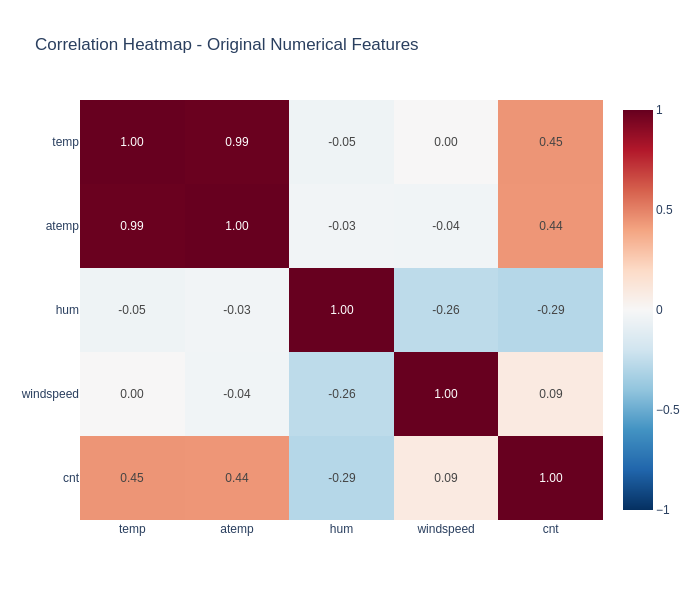

2. CORRELATION WITH ALL FEATURES (INCLUDING ENGINEERED)


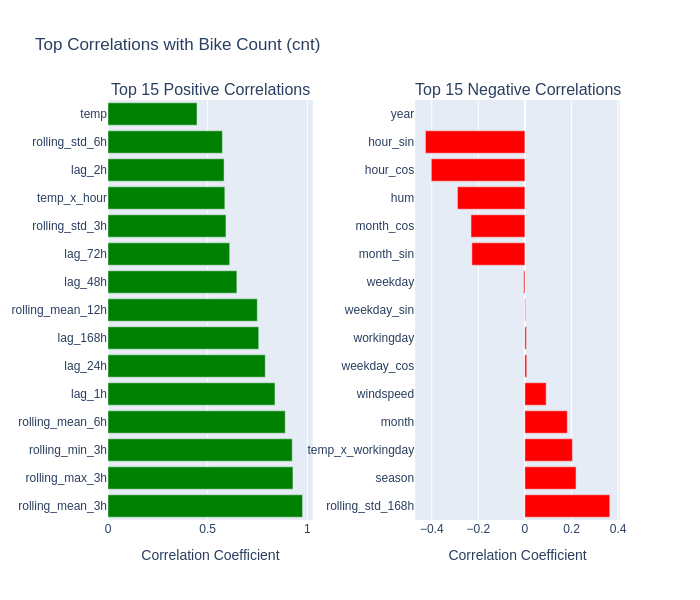

3. DETAILED CORRELATION INSIGHTS
📊 TOP 10 FEATURES CORRELATED WITH BIKE COUNT:
    1. rolling_mean_3h           :   0.976
    2. rolling_max_3h            :   0.928
    3. rolling_min_3h            :   0.924
    4. rolling_mean_6h           :   0.889
    5. lag_1h                    :   0.837
    6. lag_24h                   :   0.789
    7. lag_168h                  :   0.756
    8. rolling_mean_12h          :   0.749
    9. lag_48h                   :   0.646
   10. lag_72h                   :   0.610

📊 STRONGEST POSITIVE CORRELATIONS (> 0.3):
   - rolling_mean_3h: 0.976
   - rolling_max_3h: 0.928
   - rolling_min_3h: 0.924
   - rolling_mean_6h: 0.889
   - lag_1h: 0.837

📊 STRONGEST NEGATIVE CORRELATIONS (< -0.1):
   - month_sin: -0.228
   - month_cos: -0.231
   - hum: -0.290
   - hour_cos: -0.402
   - hour_sin: -0.427

4. FEATURE GROUP CORRELATION ANALYSIS
📈 AVERAGE CORRELATION BY FEATURE GROUP:
   - Temporal       : 0.312 (avg absolute correlation)
   - Weather        : 0.352 (avg

In [60]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def correlation_analysis(train_ts, train_final):

    # 1. Correlation with Original Features Only
    print("1. CORRELATION WITH ORIGINAL FEATURES")

    # Select numerical original features
    original_numerical = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
    corr_original = train_ts[original_numerical].corr()

    fig_original = px.imshow(corr_original,
                           title="Correlation Heatmap - Original Numerical Features",
                           color_continuous_scale='RdBu_r',
                           aspect="auto",
                           zmin=-1, zmax=1,
                           text_auto='.2f')
    fig_original.update_layout(height=600)
    fig_original.show()

    # 2. Correlation with All Features (Including Engineered)
    print("2. CORRELATION WITH ALL FEATURES (INCLUDING ENGINEERED)")

    # Select numerical features from engineered dataset (exclude categorical and datetime)
    numerical_cols = train_final.select_dtypes(include=[np.number]).columns.tolist()

    # Calculate correlation with target
    corr_with_target = train_final[numerical_cols].corr()['cnt'].sort_values(ascending=False)

    # Top 15 positive and negative correlations
    top_positive = corr_with_target[1:16]  # Exclude cnt itself
    top_negative = corr_with_target[-15:]

    # Create subplots for top correlations
    fig = make_subplots(rows=1, cols=2,
                       subplot_titles=('Top 15 Positive Correlations', 'Top 15 Negative Correlations'),
                       horizontal_spacing=0.2)

    # Positive correlations
    fig.add_trace(
        go.Bar(y=top_positive.index, x=top_positive.values,
               orientation='h', marker_color='green', name='Positive'),
        row=1, col=1
    )

    # Negative correlations
    fig.add_trace(
        go.Bar(y=top_negative.index, x=top_negative.values,
               orientation='h', marker_color='red', name='Negative'),
        row=1, col=2
    )

    fig.update_layout(
        title_text="Top Correlations with Bike Count (cnt)",
        height=600,
        showlegend=False
    )

    fig.update_xaxes(title_text="Correlation Coefficient", row=1, col=1)
    fig.update_xaxes(title_text="Correlation Coefficient", row=1, col=2)

    fig.show()

    # 3. Detailed Correlation Analysis
    print("3. DETAILED CORRELATION INSIGHTS")

    print("📊 TOP 10 FEATURES CORRELATED WITH BIKE COUNT:")
    for i, (feature, corr) in enumerate(corr_with_target.head(11).items()):  # Include cnt itself
        if feature != 'cnt':
            print(f"   {i:2d}. {feature:25} : {corr:7.3f}")

    print(f"\n📊 STRONGEST POSITIVE CORRELATIONS (> 0.3):")
    strong_positive = corr_with_target[corr_with_target > 0.3].index.tolist()
    strong_positive = [feat for feat in strong_positive if feat != 'cnt']
    for feat in strong_positive[:5]:
        print(f"   - {feat}: {corr_with_target[feat]:.3f}")

    print(f"\n📊 STRONGEST NEGATIVE CORRELATIONS (< -0.1):")
    strong_negative = corr_with_target[corr_with_target < -0.1].index.tolist()
    for feat in strong_negative[:5]:
        print(f"   - {feat}: {corr_with_target[feat]:.3f}")

    # 4. Feature Group Correlation Analysis
    print("\n4. FEATURE GROUP CORRELATION ANALYSIS")

    feature_groups = {
        'Temporal': [col for col in numerical_cols if 'hr' in col or 'mnth' in col or 'season' in col],
        'Weather': [col for col in numerical_cols if 'temp' in col or 'hum' in col or 'windspeed' in col or 'weather' in col],
        'Time-based': [col for col in numerical_cols if 'is_' in col and 'lag' not in col],
        'Lag Features': [col for col in numerical_cols if 'lag' in col or 'diff' in col],
        'Rolling Stats': [col for col in numerical_cols if 'rolling' in col or 'ema' in col or 'z_score' in col]
    }

    print("📈 AVERAGE CORRELATION BY FEATURE GROUP:")
    for group, features in feature_groups.items():
        if features:
            avg_corr = corr_with_target[features].abs().mean()
            print(f"   - {group:15}: {avg_corr:.3f} (avg absolute correlation)")

    return corr_with_target

# Execute correlation analysis
correlation_results = correlation_analysis(train_ts, train_final_clean)



---



**Time-aware** Visualization

1. HOURLY PATTERNS - BOXPLOTS


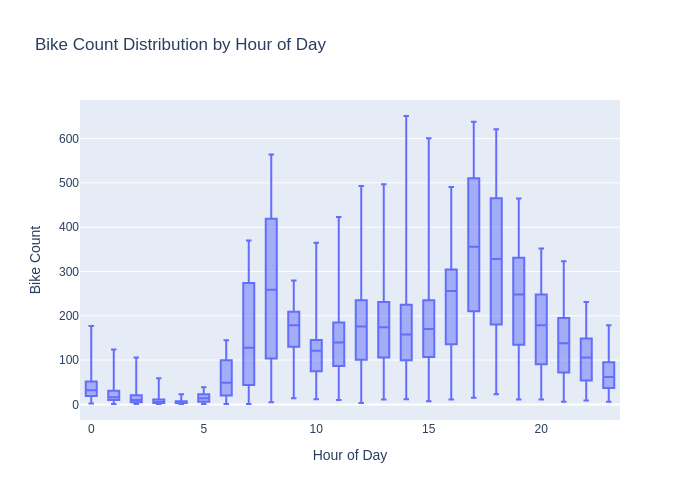

2. SEASONAL PATTERNS - LINEPLOTS


/tmp/ipykernel_7652/2906304412.py:18: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



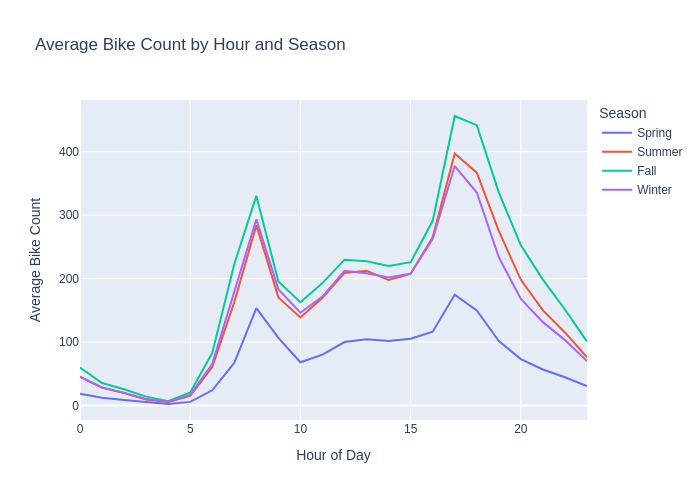

3. WEATHER PATTERNS - LINEPLOTS


/tmp/ipykernel_7652/2906304412.py:34: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



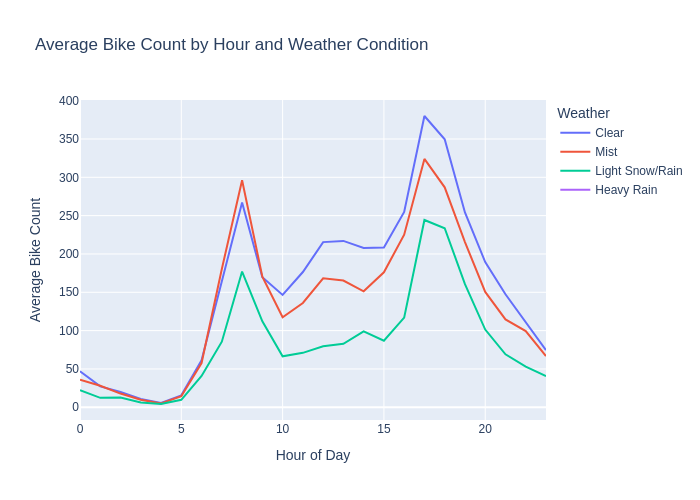

4. WEEKDAY VS WEEKEND PATTERNS


/tmp/ipykernel_7652/2906304412.py:53: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



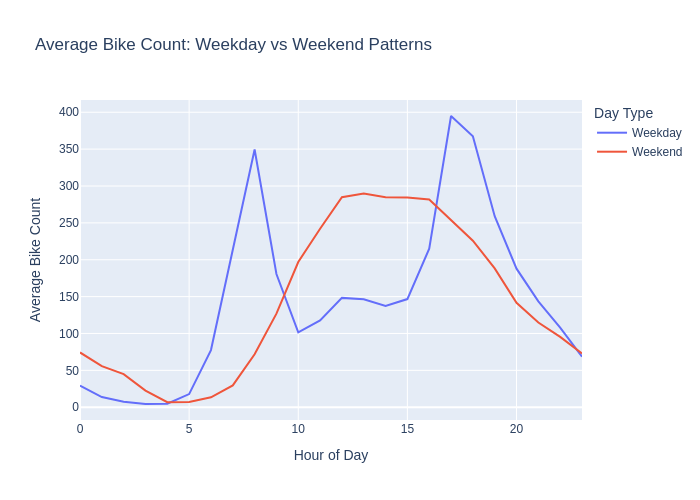

5. WORKING DAY VS HOLIDAY PATTERNS


/tmp/ipykernel_7652/2906304412.py:64: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



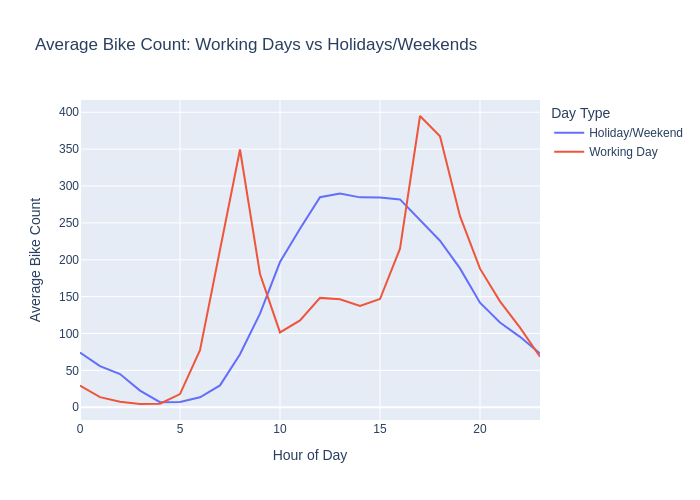

6. MULTI-DIMENSIONAL ANALYSIS: SEASON × WEATHER


/tmp/ipykernel_7652/2906304412.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_7652/2906304412.py:81: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



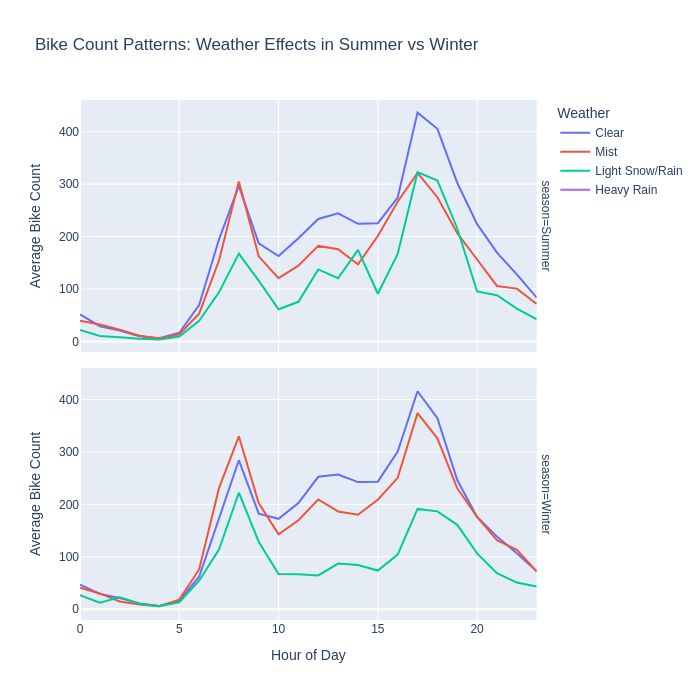


7. PATTERN ANALYSIS SUMMARY
📊 PEAK USAGE HOURS BY CONDITION:
   - Overall peak hour: 17:00
   - Spring peak hour: 17:00
   - Summer peak hour: 17:00
   - Fall peak hour: 17:00
   - Winter peak hour: 17:00

📊 USAGE INTENSITY:
   - Peak hours (7-9, 16-18) average: 250.9 bikes
   - Off-peak hours (0-5) average: 19.9 bikes
   - Peak/Off-peak ratio: 12.6x

📊 WEATHER IMPACT:
   - Clear weather average: 155.8 bikes
   - Bad weather average: 87.0 bikes
   - Weather impact ratio: 1.8x


/tmp/ipykernel_7652/2906304412.py:101: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_7652/2906304412.py:106: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_7652/2906304412.py:106: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_7652/2906304412.py:106: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

In [63]:
def time_aware_visualization(train_ts):

    # 1. Boxplots by Hour
    print("1. HOURLY PATTERNS - BOXPLOTS")

    # Create hourly boxplot
    fig_hourly = px.box(train_ts, x='hour', y='cnt',
                       title='Bike Count Distribution by Hour of Day',
                       labels={'hour': 'Hour of Day', 'cnt': 'Bike Count'})
    fig_hourly.update_layout(height=500, showlegend=False)
    fig_hourly.update_traces(boxpoints=False)  # Remove individual points for clarity
    fig_hourly.show()

    # 2. Lineplots by Season
    print("2. SEASONAL PATTERNS - LINEPLOTS")

    # Calculate average bike count by hour and season
    hourly_seasonal = train_ts.groupby(['hour', 'season'])['cnt'].mean().reset_index()

    # Map season numbers to names
    season_names = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    hourly_seasonal['season_name'] = hourly_seasonal['season'].map(season_names)

    fig_seasonal = px.line(hourly_seasonal, x='hour', y='cnt', color='season_name',
                          title='Average Bike Count by Hour and Season',
                          labels={'hour': 'Hour of Day', 'cnt': 'Average Bike Count', 'season_name': 'Season'})
    fig_seasonal.update_layout(height=500)
    fig_seasonal.show()

    # 3. Lineplots by Weather Situation
    print("3. WEATHER PATTERNS - LINEPLOTS")

    # Calculate average bike count by hour and weather situation
    hourly_weather = train_ts.groupby(['hour', 'weathersit'])['cnt'].mean().reset_index()

    # Map weather situation to names
    weather_names = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
    hourly_weather['weather_name'] = hourly_weather['weathersit'].map(weather_names)

    fig_weather = px.line(hourly_weather, x='hour', y='cnt', color='weather_name',
                         title='Average Bike Count by Hour and Weather Condition',
                         labels={'hour': 'Hour of Day', 'cnt': 'Average Bike Count', 'weather_name': 'Weather'})
    fig_weather.update_layout(height=500)
    fig_weather.show()

    # 4. Weekday vs Weekend Patterns
    print("4. WEEKDAY VS WEEKEND PATTERNS")

    # Create weekend flag for this analysis
    train_ts_temp = train_ts.copy()
    train_ts_temp['day_type'] = train_ts_temp['weekday'].isin([0, 6]).map({True: 'Weekend', False: 'Weekday'})

    hourly_daytype = train_ts_temp.groupby(['hour', 'day_type'])['cnt'].mean().reset_index()

    fig_daytype = px.line(hourly_daytype, x='hour', y='cnt', color='day_type',
                         title='Average Bike Count: Weekday vs Weekend Patterns',
                         labels={'hour': 'Hour of Day', 'cnt': 'Average Bike Count', 'day_type': 'Day Type'})
    fig_daytype.update_layout(height=500)
    fig_daytype.show()

    # 5. Working Day vs Holiday Patterns
    print("5. WORKING DAY VS HOLIDAY PATTERNS")

    hourly_work_holiday = train_ts.groupby(['hour', 'workingday'])['cnt'].mean().reset_index()
    hourly_work_holiday['day_type'] = hourly_work_holiday['workingday'].map({1: 'Working Day', 0: 'Holiday/Weekend'})

    fig_work_holiday = px.line(hourly_work_holiday, x='hour', y='cnt', color='day_type',
                              title='Average Bike Count: Working Days vs Holidays/Weekends',
                              labels={'hour': 'Hour of Day', 'cnt': 'Average Bike Count', 'day_type': 'Day Type'})
    fig_work_holiday.update_layout(height=500)
    fig_work_holiday.show()

    # 6. Multi-dimensional Analysis: Season × Weather
    print("6. MULTI-DIMENSIONAL ANALYSIS: SEASON × WEATHER")

    # Sample analysis: Summer vs Winter in different weather conditions
    summer_data = train_ts[train_ts['season'] == 2]  # Summer
    winter_data = train_ts[train_ts['season'] == 4]  # Winter

    summer_weather = summer_data.groupby(['hour', 'weathersit'])['cnt'].mean().reset_index()
    winter_weather = winter_data.groupby(['hour', 'weathersit'])['cnt'].mean().reset_index()

    summer_weather['season'] = 'Summer'
    winter_weather['season'] = 'Winter'
    combined_weather = pd.concat([summer_weather, winter_weather])
    combined_weather['weather_name'] = combined_weather['weathersit'].map(weather_names)

    fig_combined = px.line(combined_weather, x='hour', y='cnt', color='weather_name', facet_row='season',
                          title='Bike Count Patterns: Weather Effects in Summer vs Winter',
                          labels={'hour': 'Hour of Day', 'cnt': 'Average Bike Count', 'weather_name': 'Weather'})
    fig_combined.update_layout(height=700)
    fig_combined.show()

    # 7. Statistical Summary of Patterns
    print("\n7. PATTERN ANALYSIS SUMMARY")

    # Peak hours by different conditions
    print("📊 PEAK USAGE HOURS BY CONDITION:")

    # Overall peak
    overall_peak = train_ts.groupby('hour')['cnt'].mean().idxmax()
    print(f"   - Overall peak hour: {overall_peak}:00")

    # Peak by season
    for season_num, season_name in season_names.items():
        season_peak = train_ts[train_ts['season'] == season_num].groupby('hour')['cnt'].mean().idxmax()
        print(f"   - {season_name} peak hour: {season_peak}:00")

    # Usage ratio: Peak vs Off-peak
    peak_hours = [7, 8, 9, 16, 17, 18]
    off_peak_hours = [0, 1, 2, 3, 4, 5]

    peak_avg = train_ts[train_ts['hour'].isin(peak_hours)]['cnt'].mean()
    off_peak_avg = train_ts[train_ts['hour'].isin(off_peak_hours)]['cnt'].mean()

    print(f"\n📊 USAGE INTENSITY:")
    print(f"   - Peak hours (7-9, 16-18) average: {peak_avg:.1f} bikes")
    print(f"   - Off-peak hours (0-5) average: {off_peak_avg:.1f} bikes")
    print(f"   - Peak/Off-peak ratio: {peak_avg/off_peak_avg:.1f}x")

    # Weather impact
    clear_avg = train_ts[train_ts['weathersit'] == 1]['cnt'].mean()
    bad_weather_avg = train_ts[train_ts['weathersit'] >= 3]['cnt'].mean()

    print(f"\n📊 WEATHER IMPACT:")
    print(f"   - Clear weather average: {clear_avg:.1f} bikes")
    print(f"   - Bad weather average: {bad_weather_avg:.1f} bikes")
    print(f"   - Weather impact ratio: {clear_avg/bad_weather_avg:.1f}x")

# Execute time-aware visualization
time_aware_visualization(train_ts)



---



**Cross-Filtering** Visualization

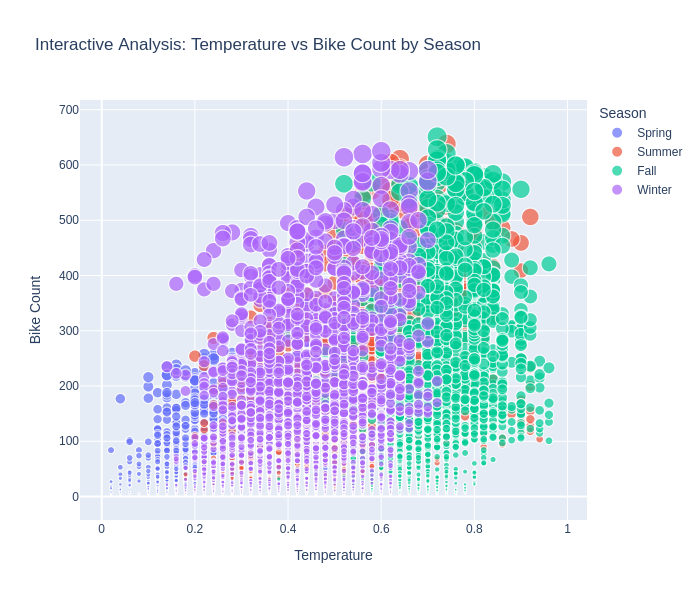

2. FACETED HOURLY PATTERNS


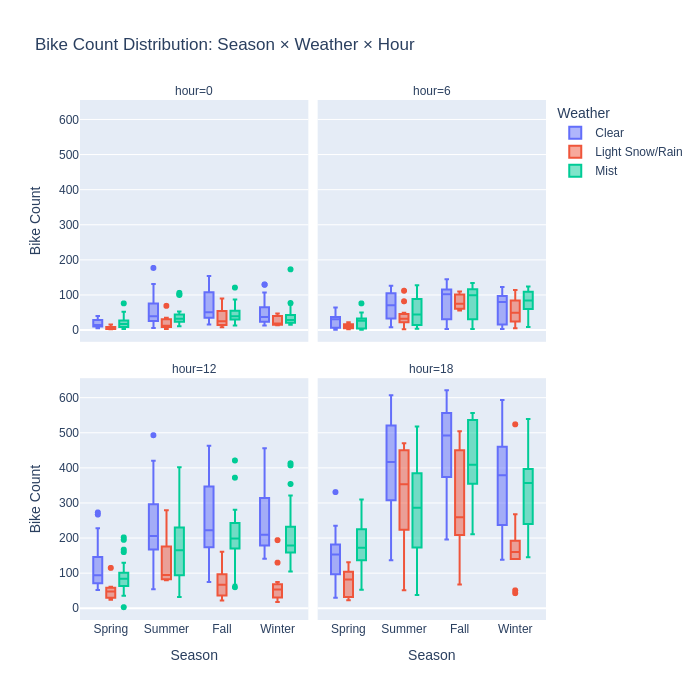

In [64]:
def interactive_cross_analysis(train_ts):

    # Prepare data for interactive plot
    df_viz = train_ts.copy()

    # Create meaningful labels
    df_viz['season_name'] = df_viz['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
    df_viz['weather_name'] = df_viz['weathersit'].map({1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'})
    df_viz['day_type'] = df_viz['weekday'].isin([0, 6]).map({True: 'Weekend', False: 'Weekday'})

    # Create interactive scatter plot
    fig = px.scatter(df_viz, x='temp', y='cnt', color='season_name',
                    size='cnt', hover_data=['hour', 'weather_name', 'day_type'],
                    title='Interactive Analysis: Temperature vs Bike Count by Season',
                    labels={'temp': 'Temperature', 'cnt': 'Bike Count', 'season_name': 'Season'})

    fig.update_layout(height=600)
    fig.show()

    # 2. Hourly patterns with multiple facets
    print("2. FACETED HOURLY PATTERNS")

    # Sample data for clarity
    sample_hours = df_viz[df_viz['hour'].isin([0, 6, 12, 18])]  # 4 key hours

    fig_facet = px.box(sample_hours, x='season_name', y='cnt', color='weather_name',
                      facet_col='hour', facet_col_wrap=2,
                      title='Bike Count Distribution: Season × Weather × Hour',
                      labels={'season_name': 'Season', 'cnt': 'Bike Count', 'weather_name': 'Weather'})

    fig_facet.update_layout(height=700)
    fig_facet.show()

# Execute interactive analysis
interactive_cross_analysis(train_ts)



---



# Fitting a **Quantile Regression** Model

In [65]:
!pip install statsmodels

In [66]:
import pandas as pd
import statsmodels.formula.api as smf

# Load the training data if not already loaded (assuming train_final_clean is available)
# train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final Project/hour_train_final_clean.csv")

# Ensure 'season' is treated as a categorical variable in the formula
# The formula uses C() to indicate categorical variables and : for interactions
formula = 'cnt ~ C(season) + temp + C(season):temp'

# Perform Quantile Regression for the median (tau=0.5)
# You can change tau to other values (e.g., 0.1 for 10th percentile, 0.9 for 90th percentile)
quant_reg_median = smf.quantreg(formula, train_final_clean).fit(q=0.5)

# Print the summary of the regression results
print(quant_reg_median.summary())

                         QuantReg Regression Results                          
Dep. Variable:                    cnt   Pseudo R-squared:               0.1490
Model:                       QuantReg   Bandwidth:                       24.46
Method:                 Least Squares   Sparsity:                        219.6
Date:                Sat, 28 Mar 2026   No. Observations:                 8406
Time:                        14:23:01   Df Residuals:                     8398
                                        Df Model:                            7
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.3333      6.449      0.362      0.718     -10.309      14.975
C(season)[T.2]        -70.6667     10.690     -6.610      0.000     -91.622     -49.711
C(season)[T.3]       -268.3333     18.765    -14.299      0.000    -305.118    -231.549
C(seaso

The summary of the Quantile Regression model will provide coefficients, standard errors, t-statistics, p-values, and confidence intervals for each predictor (season, temp, and their interaction).

*   **P-value:** Look at the p-value for each term. A p-value less than your chosen significance level (e.g., 0.05) indicates that the predictor has a statistically significant effect on the median bike count, after accounting for the other predictors in the model.
*   **Coefficients:** The coefficients represent the estimated change in the median bike count associated with a one-unit increase in the predictor, holding other predictors constant. For categorical variables like 'season', the coefficients represent the difference in median bike count compared to the reference category (usually the first level).
*   **Interaction Term (C(season):temp):** The p-value for the interaction term tells you if the relationship between temperature and median bike count is significantly different across the different seasons. If the interaction is significant, it means the effect of temperature depends on the season, and vice versa.